In [1]:
import copy
from abc import abstractmethod

from praca_magisterska.v2.HelpfullFunctions import parse_infix








In [2]:
class Term():
    @abstractmethod
    def __init__(self):
        pass

In [3]:
relationId = 0
class Relation:
    def __init__(self, name:str, arity:[int]):
        global relationId
        self.name = name
        arity.sort()
        self.arity = arity
        self.id = relationId
        relationId += 1
    def __str__(self):
        return(self.name)
    def __repr__(self):
        return "R" + str(self.id)
    def __eq__(self,other):
        if not isinstance(other,Relation):
            raise TypeError("Bad argument type")
        return self.id == other.id

In [4]:
variableId = 0
class Variable(Term):
    def __init__(self,name:str):
        global variableId
        self.name = name
        self.id = variableId
        variableId += 1
    def __eq__(self,other):
        if not isinstance(other,Variable):
            raise TypeError("Bad argument type")
        return self.name == other.name
    def __str__(self):
        return self.name
    def __repr__(self):
        return self.name
        #return "V"+str(self.id)
    def __hash__(self):
        return hash(self.__str__())
        #return hash(self.__repr__())


In [5]:
functionId = 0
class Function_without_argument:
    def __init__(self, name:str, arity:[int]):
        global functionId
        self.id = functionId
        functionId += 1
        self.name = name
        arity.sort()
        self.arity = arity
    def __str__(self):
        return(self.name)
    def __repr__(self):
        return "F" + str(self.id)
    def __eq__(self,other):
        if not isinstance(other,Function_without_argument):
            raise TypeError("Bad argument type")
        return self.__repr__() == other.__repr__()

In [6]:
class Function_with_argument(Term): #dopisać str , eq itp
    def __init__(self,Function,*Arguments):
        if not isinstance(Function,Function_without_argument):
            raise TypeError("Bad argument type")
        self.Function = Function
        for i in Arguments:
            if not isinstance(i,Term):
                raise TypeError("Bad argument type")
        if not Arguments.__len__() in Function.arity:
            raise TypeError("Bad argument type")
        self.Arguments = Arguments
    def __eq__(self,other):
        if not isinstance(other,Function_with_argument):
            return False
        if self.Function != other.Function:
            return False
        if self.Arguments.__len__() != other.Arguments.__len__():
            return False
        for i in range(self.Arguments.__len__()):
            if self.Arguments[i] != other.Arguments[i]:
                return False
        return True
    def __str__(self):
        ans = self.Function.__str__()
        ans +="("
        for i in self.Arguments:
            ans += i.__str__()
            ans += ","
        ans = ans[:-1]
        ans += ")"
        return ans
    def __repr__(self):
        ans = self.Function.__repr__()
        ans +="("
        for i in self.Arguments:
            ans += i.__repr__()
            ans += ","
        ans = ans[:-1]
        ans += ")"
        return ans
    def __hash__(self):
        return hash(self.__str__())
        #return hash(self.__repr__())



In [7]:
class Formula:
    def which_type(self):
        if isinstance(self,Truth):
            return "Truth"
        if isinstance(self,Lie):
            return "Lie"
        if isinstance(self,Atom):
            return "Atom"
        if isinstance(self,Negation):
            return "Negation"
        if isinstance(self,Conjunction):
            return "Conjunction"
        if isinstance(self,Disjunction):
            return "Disjunction"
        if isinstance(self,Implication):
            return "Implication"
        if isinstance(self,Forall):
            return "Forall"
        if isinstance(self,Exists):
            return "Exists"
        if isinstance(self,Iff):
            return "Iff"
        if isinstance(self,Equal):
            return "Equal"
    def __eq__(self,other):
        if isinstance(other,Term):
            return False
        if not isinstance(other,Formula):
            raise TypeError("Bad argument")
        if self.which_type() != other.which_type():
            return False
        return True
    @abstractmethod
    def __str__(self):
        pass
    @abstractmethod
    def __repr__(self):
        pass
    @abstractmethod
    def __init__(self):
        self.Interior = []
    def is_simple(self):
        if self.which_type() == "Truth":
            return True
        if self.which_type() == "Lie":
            return True
        if self.which_type() == "Atom":
            return True
        if self.which_type() == "Negation":
            return True
        return False
    #simpliffying methods
    def Left(self):
        return self.Interior[0]
    def Right(self):
        return self.Interior[1]
    def Content(self):
        return self.Interior[0]
    def __hash__(self):
        return hash(self.__str__())
        #return hash(self.__repr__())


In [8]:
class Truth(Formula):
    def __init__(self):
        return None
    def __eq__(self,other):
        if not isinstance(other,Truth):
            return False
        else:
            return True
    def __str__(self):
        return "T"
    def __repr__(self):
        return "T"
    __hash__ = Formula.__hash__
    def evaluate(self,values):
        return Truth()



In [9]:
class Lie(Formula):
    def __init__(self):
        return None
    def __eq__(self,other):
        if not isinstance(other,Lie):
            return False
        else:
            return True
    def __str__(self):
        return "⊥"
    def __repr__(self):
        return "⊥"
    __hash__ = Formula.__hash__
    def evaluate(self,values):
        return Lie()
print(Lie())

⊥


In [10]:
class Atom(Formula):
    @staticmethod
    def are_args_ok(args):
        if not type(args[0]) == Relation:
            return False
        for i in args[0].arity:
            if len(args) == i+1:
                for j in args[1:]:
                    if not isinstance(j,Term):
                        return False
                return True
        return False
    def __init__(self,*args):
        if not Atom.are_args_ok(args):
            raise TypeError("Bad arguments")
        self.Relation = args[0]
        self.Arguments = args[1:]
    def __eq__(self, other):
        if super().__eq__(other):
            if not (self.Relation == other.Relation and
                    len(self.Arguments) == len(other.Arguments)):
                return False
            else:
                ans = True
                for i in zip(self.Arguments, other.Arguments):
                    if i[0] != i[1]:
                        return False
                return True
        else:
            return False
    def __str__(self):
        ans = self.Relation.__str__()
        ans +="("
        for i in self.Arguments:
            ans += i.__str__()
            ans += ","
        ans = ans[:-1]
        ans += ")"
        return ans
    def __repr__(self):
        ans = self.Relation.__repr__()
        ans +="("
        for i in self.Arguments:
            ans += i.__repr__()
            ans += ","
        ans = ans[:-1]
        ans += ")"
        return ans
    __hash__ = Formula.__hash__
    def evaluate(self,values):
        return values[self]

In [11]:
x = Variable("x")
R = Relation("R",[1])
a = Atom(R,x)
b = Atom(R,x)
print(a.__str__())
print(b.__str__())

R(x)
R(x)


In [12]:
class Negation(Formula):
    @staticmethod
    def are_args_ok(args):
        return (len(args) == 1) and isinstance(args[0], Formula)
    def __init__(self,*args):
        if not Negation.are_args_ok(args):
            raise TypeError("Bad arguments")
        self.Interior = [args[0]]
    def __eq__(self, other):
        if super().__eq__(other):
            return self.Interior[0] == other.Interior[0]
        else:
            return False
    def __str__(self):
        if self.Interior[0].is_simple():
            return "~" + self.Interior[0].__str__()
        else:
            return "~(" + self.Interior[0].__str__() +")"
    def __repr__(self):
        if self.Interior[0].is_simple():
            return "~" + self.Interior[0].__repr__()
        else:
            return "~(" + self.Interior[0].__repr__() +")"
    __hash__ = Formula.__hash__
    def evaluate(self,values):
        v = self.Interior[0].evaluate(values)
        if v == Truth():
            return Lie()
        else:
            return Truth()


In [13]:
class Conjunction(Formula):
    @staticmethod
    def are_args_ok(args):
        for i in args:
            if not isinstance(i, Formula):
                return False
        return True
    def __init__(self,*args):
        if not Conjunction.are_args_ok(args):
            raise TypeError("Bad arguments")
        self.Interior = list(args)
    def __eq__(self, other):
        if super().__eq__(other) and len(self.Interior) == len(other.Interior):
            for i in zip(self.Interior, other.Interior):
                if i[0] != i[1]:
                    return False
            return True
        else:
            return False
    def __str__(self):
        def str(f:Formula):
            if f.is_simple():
                return f.__str__()
            else:
                return "(" + f.__str__() + ")"
        ans = ""
        for i in self.Interior:
            ans += str(i) + " & "
        return ans[:-3]
    def __repr__(self):
        def repr(f:Formula):
            if f.is_simple():
                return f.__repr__()
            else:
                return "(" + f.__repr__() + ")"
        ans = ""
        for i in self.Interior:
            ans += repr(i) + " & "
        return ans[:-3]
    __hash__=Formula.__hash__
    def evaluate(self,values):
        for i in self.Interior:
            if i.evaluate(values) == Lie():
                return Lie()
        return Truth()

In [14]:
class Disjunction(Formula):
    @staticmethod
    def are_args_ok(args):
        for i in args:
            if not isinstance(i, Formula):
                return False
        return True
    def __init__(self,*args):
        if not Disjunction.are_args_ok(args):
            raise TypeError("Bad arguments")
        self.Interior = list(args)
    def __eq__(self, other):
        if super().__eq__(other) and len(self.Interior) == len(other.Interior):
            for i in zip(self.Interior, other.Interior):
                if i[0] != i[1]:
                    return False
            return True
        else:
            return False
    def __str__(self):
        def str(f:Formula):
            if f.is_simple():
                return f.__str__()
            else:
                return "(" + f.__str__() + ")"
        ans = ""
        for i in self.Interior:
            ans += str(i) + " | "
        return ans[:-3]
    def __repr__(self):
        def repr(f:Formula):
            if f.is_simple():
                return f.__repr__()
            else:
                return "(" + f.__repr__() + ")"
        ans = ""
        for i in self.Interior:
            ans += repr(i) + " | "
        return ans[:-3]
    __hash__=Formula.__hash__
    def evaluate(self,values):
        for i in self.Interior:
            if i.evaluate(values) == Truth():
                return Truth()
        return Lie()


In [15]:
class Implication(Formula):
    @staticmethod
    def are_args_ok(args):
        if len(args) != 2:
            raise TypeError("Bad arguments")
        return isinstance(args[0], Formula) and isinstance(args[1], Formula)
    def __init__(self,*args):
        if not Implication.are_args_ok(args):
            raise TypeError("Bad arguments")
        self.Interior = list(args)
    def __eq__(self, other):
        if super().__eq__(other) and len(self.Interior) == len(other.Interior):
            return self.Interior[0] == other.Interior[0] and self.Interior[1] == other.Interior[1]
        else:
            return False
    def __str__(self):
        def str(f:Formula):
            if f.is_simple():
                return f.__str__()
            else:
                return "(" + f.__str__() + ")"
        return str(self.Interior[0]) + " -> " + str(self.Interior[1])
    def __repr__(self):
        def repr(f:Formula):
            if f.is_simple():
                return f.__repr__()
            else:
                return "(" + f.__repr__() + ")"
        return repr(self.Interior[0]) + " -> " + repr(self.Interior[1])
    __hash__=Formula.__hash__
    def evaluate(self,values):
        if self.Left().evaluate(values) == Lie():
            return Truth()
        else:
            return self.Right().evaluate(values)

In [16]:
class Iff(Formula):
    @staticmethod
    def are_args_ok(args):
        if len(args) != 2:
            raise TypeError("Bad arguments")
        return isinstance(args[0], Formula) and isinstance(args[1], Formula)
    def __init__(self,*args):
        if not Iff.are_args_ok(args):
            raise TypeError("Bad arguments")
        self.Interior = list(args)
    def __eq__(self, other):
        if super().__eq__(other) and len(self.Interior) == len(other.Interior):
            for i in zip(self.Interior, other.Interior):
                if i[0] != i[1]:
                    return False
            return True
        else:
            return False
    def __str__(self):
        def str(f:Formula):
            if f.is_simple():
                return f.__str__()
            else:
                return "(" + f.__str__() + ")"
        return str(self.Interior[0]) + " <-> " + str(self.Interior[1])
    def __repr__(self):
        def repr(f:Formula):
            if f.is_simple():
                return f.__repr__()
            else:
                return "(" + f.__repr__() + ")"
        return repr(self.Interior[0]) + " <-> " + repr(self.Interior[1])
    __hash__=Formula.__hash__
    def evaluate(self,values):
        if self.Left().evaluate(values) == self.Right().evaluate(values):
            return Truth()
        else:
            return Lie()

In [17]:
class Equal(Formula):
    @staticmethod
    def are_args_ok(args):
        if len(args) != 2:
            raise TypeError("Bad arguments")
        return isinstance(args[0], Term) and isinstance(args[1], Term)
    def __init__(self,*args):
        if not Equal.are_args_ok(args):
            raise TypeError("Bad arguments")
        self.Interior = list(args)
    def __eq__(self, other):
        if super().__eq__(other) and len(self.Interior) == len(other.Interior):
            for i in zip(self.Interior, other.Interior):
                if i[0] != i[1]:
                    return False
            return True
        else:
            return False
    def __str__(self):
        return self.Interior[0].__str__() + " = " + self.Interior[1].__str__()
    def __repr__(self):
        return self.Interior[0].__repr__() + " = " + self.Interior[1].__repr__()
    __hash__=Formula.__hash__


In [18]:
F = Function_without_argument("f",[1,2])
G = Function_without_argument("g",[1])
H = Function_without_argument("h",[3])


x = Variable("x")
y = Variable("y")
z = Variable("z")

A = Function_with_argument(F,x,y)
B = Function_with_argument(G,z)
print(Equal(A,B))


f(x,y) = g(z)


In [19]:
class Forall(Formula):
    @staticmethod
    def are_args_ok(args):
        for i in args[:-1]:
            if not isinstance(i, Variable):
                return False
        return isinstance(args[-1], Formula)
    def __init__(self,*args):
        if not Forall.are_args_ok(args):
            raise TypeError("Bad arguments")
        self.Vars = list(args[:-1])
        self.Interior = [args[-1]]
    def __eq__(self, other):
        if super().__eq__(other) and len(self.Vars) == len(other.Vars):
            for i in zip(self.Vars, other.Vars):
                if i[0] != i[1]:
                    return False
            return self.Interior[0] == other.Interior[0]
        else:
            return False
    def __str__(self):
        def str(f:Formula):
            if f.is_simple():
                return f.__str__()
            else:
                return "(" + f.__str__() + ")"
        ans = "∀"
        for i in self.Vars:
            ans += i.__str__()+","
        ans = ans[:-1]
        ans += "."
        ans += str(self.Interior[0])
        return ans
    def __repr__(self):
        def repr(f:Formula):
            if f.is_simple():
                return f.__repr__()
            else:
                return "(" + f.__repr__() + ")"
        ans = "∀"
        for i in self.Vars:
            ans += i.__repr__()+","
        ans = ans[:-1]
        ans += "."
        ans += repr(self.Interior[0])
        return ans
    __hash__=Formula.__hash__


In [20]:
class Exists(Formula):
    @staticmethod
    def are_args_ok(args):
        for i in args[:-1]:
            if not isinstance(i, Variable):
                return False
        return isinstance(args[-1], Formula)
    def __init__(self,*args):
        if not Exists.are_args_ok(args):
            raise TypeError("Bad arguments")
        self.Vars = list(args[:-1])
        self.Interior = [args[-1]]
    def __eq__(self, other):
        if super().__eq__(other) and len(self.Vars) == len(other.Vars):
            for i in zip(self.Vars, other.Vars):
                if i[0] != i[1]:
                    return False
            return self.Interior[0] == other.Interior[0]
        else:
            return False
    def __str__(self):
        def str(f:Formula):
            if f.is_simple():
                return f.__str__()
            else:
                return "(" + f.__str__() + ")"
        ans = "∃"
        for i in self.Vars:
            ans += i.__str__()+","
        ans = ans[:-1]
        ans += "."
        ans += str(self.Interior[0])
        return ans
    def __repr__(self):
        def repr(f:Formula):
            if f.is_simple():
                return f.__repr__()
            else:
                return "(" + f.__repr__() + ")"
        ans = "∃"
        for i in self.Vars:
            ans += i.__repr__()+","
        ans = ans[:-1]
        ans += "."
        ans += repr(self.Interior[0])
        return ans
    __hash__=Formula.__hash__

In [21]:
A = Relation("A",[1,2])
B = Relation("B",[1]),
C = Relation("C",[3])


x = Variable("x")
y = Variable("y")
z = Variable("z")

f = Atom(A,x,y)
print(f)
ff = Negation(f)
fff = Conjunction(ff,f,f)
ffff = Disjunction(ff,fff)
fffff = Implication(fff,fff)
g = Forall(x,y,fff)
gg = Exists(x,y,fff)
print(f)
print(ff)
print(fff)
print(ffff)
print(fffff)
print(g)
print(gg)
print(gg.Content())
print({f})
str(f)

A(x,y)
A(x,y)
~A(x,y)
~A(x,y) & A(x,y) & A(x,y)
~A(x,y) | (~A(x,y) & A(x,y) & A(x,y))
(~A(x,y) & A(x,y) & A(x,y)) -> (~A(x,y) & A(x,y) & A(x,y))
∀x,y.(~A(x,y) & A(x,y) & A(x,y))
∃x,y.(~A(x,y) & A(x,y) & A(x,y))
~A(x,y) & A(x,y) & A(x,y)
{R1(x,y)}


'A(x,y)'

# Konteksty i problemy

In [106]:
class Context:
    def __init__(self, *args):
        for i in args:
            if not isinstance(i, Formula):
                raise TypeError("Bad arguments")

        self.formulas = list(set(args))


    def __str__(self):
        ans = ""
        for i in self.formulas:
            ans += i.__str__() + ", "
        ans = ans[:-2]
        return ans
    def __repr__(self):
        ans = ""
        for i in self.formulas:
            ans += i.__repr__() + ", "
        ans = ans[:-2]
        return ans
    @staticmethod
    def union(x,y):
        if not isinstance(x,Context) or not isinstance(y,Context):
            raise TypeError("Bad arguments")
        set1 = set(x.formulas)
        set2 = set(y.formulas)
        set3  = set1.union(set2)
        return Context(*list(set3))
    @staticmethod
    def remove(x,y):
        ans  = Context(*x.formulas)
        if isinstance(y,Formula):
            for i in ans.formulas:
                if i == y:
                    #print(i)
                    ans.formulas.remove(i)
        elif isinstance(y,Context):
            for i in y.formulas:
                for j in ans.formulas:
                    if i == j:
                        ans.formulas.remove(j)
        else:
            raise TypeError("Bad arguments")
        return ans




    def __getitem__(self, index):
        return self.formulas[index]
    def __contains__(self,formula : Formula):
        for i in self.formulas:
            if i ==  formula:
                return True
        return False
    def __add__(self,other):
        if isinstance(other,Formula):
            return Context.union(self,Context(other))
        if isinstance(other,Context):
            return Context.union(self,other)
        else:
            raise TypeError("Bad arguments")
    def __sub__(self,other):
        if isinstance(other,Formula):
            return Context.remove(self,Context(other))
        elif isinstance(other,Context):
            return Context.remove(self,other)
        else:
            raise TypeError("Bad arguments")
    def __eq__(self,other):
        if isinstance(other,Context):
            return set(self.formulas) == set(other.formulas)
        else:
            raise TypeError("Bad arguments")


f = parse_infix("a")
ff = parse_infix("b")
fff = parse_infix("a")
context1 = Context(ff) + Context(f)
context2 = Context(ff)
print(context1)
print(context2)
print(context1,"                       ",context2)
c = Context.remove(context1,context2)
print(context1 == context2)

'(a), '(b)
'(b)
'(a), '(b)                         '(b)
False


In [23]:
context1 = Context(f,ff,fff)
context2 = Context(f,ff)
print(context1)
Context.remove(context1,f)
print(context1)

A(x,y), ~A(x,y) & A(x,y) & A(x,y), ~A(x,y)
A(x,y), ~A(x,y) & A(x,y) & A(x,y), ~A(x,y)


In [24]:
c = Context(f)
d = Context(ff)
print(c)
c += d
print(c)
c += fff
print(c)
c -= d
print(c)

A(x,y)
A(x,y), ~A(x,y)
A(x,y), ~A(x,y) & A(x,y) & A(x,y), ~A(x,y)
A(x,y), ~A(x,y) & A(x,y) & A(x,y)


In [25]:
c = Context(f)
d = Context(f)
print(c == d)

False


In [26]:
class LittleProblem:
    def __init__(self,assumptions,conclusion):
        if not isinstance(assumptions,Context):
            raise TypeError("Bad arguments")
        if not isinstance(conclusion,Formula):
            raise TypeError("Bad arguments")
        self.assumptions = assumptions
        self.conclusion = conclusion
    def __str__(self):
        ans = self.assumptions.__str__()
        ans += " ⊢ "
        ans += self.conclusion.__str__()
        return ans
    def __repr__(self):
        ans = self.assumptions.__repr__()
        ans += " ⊢ "
        ans += self.conclusion.__repr__()
        return ans


In [27]:
def FreeVariables(Expr):
    if not (isinstance(Expr,Term) or isinstance(Expr,Formula) or isinstance(Expr,Context)):
        raise TypeError("Bad arguments")
    if isinstance(Expr,Variable):
        return {Expr}
    if isinstance(Expr,Function_with_argument):
        ans = set()
        for i in Expr.Arguments:
            ans = ans.union(FreeVariables(i))
        return ans
    if isinstance(Expr,Atom):
        ans = set()
        for i in Expr.Arguments:
            ans =ans.union(FreeVariables(i))
        return ans
    if isinstance(Expr,Truth) or isinstance(Expr,Lie):
        return set()
    if isinstance(Expr,Negation) or isinstance(Expr,Conjunction) or isinstance(Expr,Disjunction) or isinstance(Expr,Implication) or isinstance(Expr,Iff) or isinstance(Expr,Equal):
        ans = set()
        for i in Expr.Interior:
            ans = ans.union(FreeVariables(i))
        return ans
    if isinstance(Expr,Forall) or isinstance(Expr,Exists):
        ans = FreeVariables(Expr.Interior[0])
        ans = ans.difference(set(Expr.Vars))
        return ans
    if isinstance(Expr,Context):
        ans = set()
        for i in Expr.formulas:
            ans = ans.union(FreeVariables(i))
        return ans

# Reguły dla rachunku zdań

Mimo, że w strukturze koniunkcji i alternatywy dałem możliwość tworzenia ich jako koniunkcji i alternatywy dowolnej liczby podformuł póki co będę używał ich jako alternatywy/koniunkcji jedynie 2 podformuł

In [28]:
import random
class Rule:
    @abstractmethod
    def __init__(self,a,b):
        idx = -1
        pass
    @abstractmethod
    def bottom_up(self ,x):
        pass
    @abstractmethod
    def top_down(self ,x):
        pass
    def default_weakening_oracle_bottom_up(x,*args):
        return 0

    def default_oracle_phi_bottom_up(x,*args):
        if not(isinstance(x,LittleProblem)):
            raise TypeError("Bad arguments")
        return Truth()
    def default_oracle_phi_top_down_generate(x,*args):
        if not(isinstance(x,LittleProblem)):
            raise TypeError("Bad arguments")
        return Truth()
    def default_oracle_phi_top_down_choose(x,*args):
        if not(isinstance(x,LittleProblem)):
            raise TypeError("Bad arguments")
        return random.choice(x.assumptions.formulas)

    def default_oracle_2assumptions_bottom_up(x,*args):
        if not(isinstance(x,LittleProblem)):
            raise TypeError("Bad arguments")
        ans1 = Context()
        ans2 = Context()
        choice_codes = np.random.choice([-1,0,1], x.assumptions.formulas.__len__())
        for i in range(choice_codes.__len__()):
            if choice_codes[i] == -1:
                ans2 += x.assumptions.formulas[i]
            if choice_codes[i] == 0:
                ans1 += x.assumptions.formulas[i]
                ans2 += x.assumptions.formulas[i]
            if choice_codes[i] == 1:
                ans1 += x.assumptions.formulas[i]
        return ans1,ans2

    def default_oracle_3assumptions_bottom_up(x,*args):
        if not(isinstance(x,LittleProblem)):
            raise TypeError("Bad arguments")
        ans1 = Context()
        ans2 = Context()
        ans3 = Context()
        choice_codes = np.random.choice([1,2,3,12,13,23,123], x.assumptions.formulas.__len__())
        for i in range(choice_codes.__len__()):
            if choice_codes[i] in [1,12,13,123]:
                ans1 += x.assumptions.formulas[i]
            if choice_codes[i] in [2,12,23,123]:
                ans2 += x.assumptions.formulas[i]
            if choice_codes[i] in [3,13,23,123]:
                ans3 += x.assumptions.formulas[i]
        return ans1,ans2,ans3

    def default_oracle_top_down_phi_from_nothing():
        print("default_oracle_top_down_phi_from_nothing")
        return Truth()

    def default_oracle_variable_choose(x,*args):
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        v = Variable("v")
        variables = FreeVariables(x.conclusion)
        variables = variables.difference(FreeVariables(x.assumptions))
        variables.add(v)
        return random.choice(list(variables))

    def default_oracle_term(x,*args):
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        v = Variable("v")
        return v

    def default_oracle_term_from_nothing():
        print("default_oracle_term_from_nothing")
        return Variable("v")
    def default_oracle_context():
        print("default_oracle_context")
        return Context()




In [29]:
class Assumption(Rule):
    def __init__(self,
                 oracle = Rule.default_oracle_top_down_phi_from_nothing):
        self.idx = 0
        self.oracle = oracle
    def bottom_up(self ,x):
        if (x.assumptions[0] == x.conclusion) and len(x.assumptions.formulas) == 1:
            return []
        else:
            raise TypeError("Bad arguments")
    def top_down(self,x):
        if x != []:
            raise TypeError("Bad arguments")
        phi = self.oracle()
        return LittleProblem(Context(phi),phi)



In [30]:
class Weakening(Rule):
    def __init__(self,
                 oracle_bottom_up = Rule.default_oracle_phi_top_down_choose,
                 oracle_top_down = Rule.default_oracle_phi_top_down_generate):
        self.idx = 1
        self.oracle_bottom_up = oracle_bottom_up
        self.oracle_top_down = oracle_top_down
    def bottom_up(self ,x): #może zwrócić coś nieprawdziwego
        #number_to_remove = self.oracle_bottom_up(x)
        #assumptions = Context(*(x.assumptions.formulas[:number_to_remove] +
        #                      x.assumptions.formulas[number_to_remove+1:]))
        #ans = [LittleProblem(assumptions,x.conclusion)]
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        psi = self.oracle_bottom_up(x)
        if not psi in x.assumptions.formulas:
            raise TypeError("Bad arguments")
        ans_context =  x.assumptions - Context(psi)
        ans_conclusion = x.conclusion
        return LittleProblem(ans_context,ans_conclusion)
    def top_down(self,x):
        if not x.__len__() == 1:
            raise TypeError("Bad arguments")
        if not(isinstance(x[0],LittleProblem)):
            raise TypeError("Bad arguments")

        psi = self.oracle_top_down(x[0])
        if not isinstance(psi,Formula):
            raise TypeError("Bad arguments")
        phi = x[0].conclusion
        Gamma = x[0].assumptions
        return LittleProblem(Gamma + psi, phi)



lp = LittleProblem(Context(Truth(),Lie()),Lie())
w = Weakening()
print(w)
w.bottom_up(lp)

T ⊢ ⊥

In [31]:
class ImplicationIntroduction(Rule):
    def __init__(self,
                 oracle_top_down = Rule.default_oracle_phi_top_down_choose):
        self.idx = 2
        self.oracle_top_down = oracle_top_down
    def bottom_up(self ,x): #może zwrócić coś nieprawdziwego
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        if isinstance(x.conclusion,Implication):
            ans_conclusion = x.conclusion.Right()
            ans_assumptions = x.assumptions + x.conclusion.Left()
            return [LittleProblem(ans_assumptions,ans_conclusion)]
        else:
            raise TypeError("Bad arguments")
    def top_down(self,x):
        if not x.__len__() == 1:
            raise TypeError("Bad arguments")
        if not(isinstance(x[0],LittleProblem)):
            raise TypeError("Bad arguments")
        phi = self.oracle_top_down(x[0])
        if not isinstance(phi,Formula):
            raise TypeError("Bad arguments")
        if not phi in x[0].assumptions.formulas:
            raise TypeError("Bad arguments")
        psi = x[0].conclusion
        Gamma = x[0].assumptions - phi
        return LittleProblem(Gamma, Implication(phi,psi))




In [32]:
class NegationIntroduction(Rule):
    def __init__(self,
                 oracle_top_down = Rule.default_oracle_phi_top_down_choose
                 ):
        self.idx = 3
        self.oracle_top_down = oracle_top_down
    def bottom_up(self ,x):
        if isinstance(x.conclusion,Negation):
            ans_conclusion = Lie()
            ans_assumptions = x.assumptions + x.conclusion
            return [LittleProblem(ans_assumptions,ans_conclusion)]
        else:
            raise TypeError("Bad arguments")
    def top_down(self,x):
        if x.__len__() != 1:
            raise TypeError("Bad arguments")
        if not isinstance(x[0],LittleProblem):
            raise TypeError("Bad arguments")
        if not(isinstance(x[0].conclusion,Lie)):
            raise TypeError("Bad arguments")
        if x[0].assumptions.formulas.__len__() == 0:
            raise TypeError("Bad arguments")
        phi = self.oracle_top_down(x[0])
        if not isinstance(phi,Formula):
            raise TypeError("Bad arguments")
        if not phi in x[0].assumptions.formulas:
            raise TypeError("Bad arguments")
        Gamma = x[0].assumptions - phi
        return LittleProblem(Gamma, Negation(phi))



In [33]:
class ImplicationElimination(Rule): #Trzeba przetestować!!!!

    def __init__(self,
                 oracle_assumptions_bottom_up = Rule.default_oracle_2assumptions_bottom_up,
                 oracle_phi_bottom_up =  Rule.default_oracle_phi_bottom_up
                 ):
        self.idx = 4
        self.oracle_assumptions_bottom_up = oracle_assumptions_bottom_up
        self.oracle_phi_bottom_up = oracle_phi_bottom_up
    def bottom_up(self ,x):
        if not(isinstance(x,LittleProblem)):
            raise TypeError("Bad arguments")
        Gamma1, Gamma2 = self.oracle_assumptions_bottom_up(x)
        for i in (Gamma1+Gamma2).formulas:
            if not i in x.assumptions.formulas:
                raise TypeError("Bad arguments")
        for i in x.assumptions.formulas:
            if not i in (Gamma1+Gamma2).formulas:
                raise TypeError("Bad arguments")
        phi = self.oracle_phi_bottom_up(x)
        if not isinstance(phi,Formula):
            raise TypeError("Bad arguments")
        psi = x.conclusion
        ans1 = LittleProblem(Gamma1,Implication(phi,psi))
        ans2 = LittleProblem(Gamma2,phi)
        return [ans1,ans2]
    def top_down(self,x):
        if x.__len__() != 2:
            raise TypeError("Bad arguments")
        if not (isinstance(x[0],LittleProblem) and  isinstance(x[1],LittleProblem)):
            raise TypeError("Bad arguments")
        if  not(isinstance(x[0].conclusion,Implication)):
            raise TypeError("Bad arguments")
        if x[0].conclusion.Left() != x[1].conclusion:
            raise TypeError("Bad arguments")
        psi = x[0].conclusion.Right()
        ans_assumptions = x[0].assumptions + x[1].assumptions
        return LittleProblem(ans_assumptions,psi)



In [34]:
class NegationElimination(Rule):
    def __init__(self,
                 oracle_assumptions_bottom_up = Rule.default_oracle_2assumptions_bottom_up,
                 oracle_phi_bottom_up =  Rule.default_oracle_phi_bottom_up
                 ):
        self.idx = 5
        self.oracle_assumptions_bottom_up = oracle_assumptions_bottom_up
        self.oracle_phi_bottom_up = oracle_phi_bottom_up
    def bottom_up(self ,x):
        if not(isinstance(x,LittleProblem)):
            raise TypeError("Bad arguments")
        if not(isinstance(x.conclusion,Lie)):
            raise TypeError("Bad arguments")
        Gamma1, Gamma2 = self.oracle_assumptions_bottom_up(x)
        for i in (Gamma1+Gamma2).formulas:
            if not i in x.assumptions.formulas:
                raise TypeError("Bad arguments")
        for i in x.assumptions.formulas:
            if not i in (Gamma1+Gamma2).formulas:
                raise TypeError("Bad arguments")
        phi = self.oracle_phi_bottom_up(x)
        if not isinstance(phi,Formula):
            raise TypeError("Bad arguments")
        ans1 = LittleProblem(Gamma1,Negation(phi))
        ans2 = LittleProblem(Gamma2,phi)
        return [ans1,ans2]
    def top_down(self,x):
        if x.__len__() != 2:
            raise TypeError("Bad arguments")
        if not (isinstance(x[0],LittleProblem) and isinstance(x[1],LittleProblem)):
            raise TypeError("Bad arguments")
        if not isinstance(x[0].conclusion,Negation):
            raise TypeError("Bad arguments")
        if x[0].conclusion.Left() != x[1].conclusion:
            raise TypeError("Bad arguments")
        Gamma = x[0].assumptions + x[1].assumptions
        return LittleProblem(Gamma,Lie())

In [35]:
class ConjunctionIntroduction(Rule):
    def __init__(self,
                 oracle_bottom_up = Rule.default_oracle_2assumptions_bottom_up):
        self.idx = 6
        self.oracle_bottom_up = oracle_bottom_up
    def bottom_up(self ,x):
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        if not isinstance(x.conclusion,Conjunction):
            raise TypeError("Bad arguments")
        Gamma1, Gamma2 = self.oracle_bottom_up(x)
        for i in (Gamma1+Gamma2).formulas:
            if not i in x.assumptions.formulas:
                raise TypeError("Bad arguments")
        for i in x.assumptions.formulas:
            if not i in (Gamma1+Gamma2).formulas:
                raise TypeError("Bad arguments")
        ans1 = LittleProblem(Gamma1,x.conclusion.Left())
        ans2 = LittleProblem(Gamma2,x.conclusion.Right())
        return [ans1,ans2]
    def top_down(self,x):
        if x.__len__() != 2:
            raise TypeError("Bad arguments")
        if not (isinstance(x[0],LittleProblem) and isinstance(x[1],LittleProblem)):
            raise TypeError("Bad arguments")
        assumptions = x[0].assumptions + x[1].assumptions
        conclusion = Conjunction(x[0].conclusion,x[1].conclusion)
        return LittleProblem(assumptions,conclusion)

In [36]:
class DisjunctionIntroduction1(Rule):
    def __init__(self,
                 oracle_top_down = Rule.default_oracle_phi_top_down_generate):
        self.idx = 7
        self.oracle_top_down = oracle_top_down
    def bottom_up(self ,x):
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        if not isinstance(x.conclusion,Disjunction):
            raise TypeError("Bad arguments")
        ans = LittleProblem(x.assumptions,x.conclusion.Left())
        return [ans]
    def top_down(self,x):
        if x.__len__() != 1:
            raise TypeError("Bad arguments")
        if not isinstance(x[0],LittleProblem):
            raise TypeError("Bad arguments")
        psi = self.oracle_top_down(x[0])
        if not isinstance(psi,Formula):
            raise TypeError("Bad arguments")
        phi = x[0].conclusion
        Gamma = x[0].assumptions
        return LittleProblem(Gamma,Disjunction(phi,psi))


In [37]:
class DisjunctionIntroduction2(Rule):
    def __init__(self,
                 oracle_top_down = Rule.default_oracle_phi_top_down_generate):
        self.idx = 8
        self.oracle_top_down = oracle_top_down
    def bottom_up(self ,x):
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        if not isinstance(x.conclusion,Disjunction):
            raise TypeError("Bad arguments")
        ans = LittleProblem(x.assumptions,x.conclusion.Right())
        return [ans]
    def top_down(self,x):
        if x.__len__() != 1:
            raise TypeError("Bad arguments")
        if not isinstance(x[0],LittleProblem):
            raise TypeError("Bad arguments")
        phi = self.oracle_top_down(x[0])
        if not isinstance(phi,Formula):
            raise TypeError("Bad arguments")
        psi = x[0].conclusion
        Gamma = x[0].assumptions
        return LittleProblem(Gamma,Disjunction(phi,psi))



In [38]:
class TruthIntroduction(Rule):
    def __init__(self):
        self.idx = 9
    def bottom_up(self ,x):
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        if not isinstance(x.conclusion,Truth):
            raise TypeError("Bad arguments")
        if not x.assumptions.formulas.__len__() == 0:
            raise TypeError("Bad arguments")
        else:
            return []
    def top_down(self,x):
        if x != []:
            raise TypeError("Bad arguments")
        return LittleProblem(Context(),Truth())

In [39]:
class ConjunctionElimination1(Rule):
    def __init__(self,
                 oracle_psi_bottom_up = Rule.default_oracle_phi_bottom_up):
        self.idx = 10
        self.oracle_psi_bottom_up = oracle_psi_bottom_up
    def bottom_up(self ,x):
        ans_assumptions = x.assumptions
        psi = self.oracle_psi_bottom_up(x)
        if not isinstance(psi,Formula):
            raise TypeError("Bad arguments")
        ans_conclusion = Conjunction(x.conclusion,psi)
        return [LittleProblem(ans_assumptions,ans_conclusion)]
    def top_down(self,x):
        if x.__len__() != 1:
            raise TypeError("Bad arguments")
        if not isinstance(x[0],LittleProblem):
            raise TypeError("Bad arguments")
        if not isinstance(x[0].conclusion,Conjunction):
            raise TypeError("Bad arguments")
        Lambda = x[0].assumptions
        phi = x[0].conclusion.Left()
        return LittleProblem(Lambda,phi)

In [40]:
class ConjunctionElimination2(Rule):
    def __init__(self,
                 oracle_phi_bottom_up = Rule.default_oracle_phi_bottom_up):
        self.idx = 11
        self.oracle_phi_bottom_up = oracle_phi_bottom_up
    def bottom_up(self ,x):
        ans_assumptions = x.assumptions
        phi = self.oracle_phi_bottom_up(x)
        if not isinstance(phi,Formula):
            raise TypeError("Bad arguments")
        ans_conclusion = Conjunction(phi,x.conclusion)
        return [LittleProblem(ans_assumptions,ans_conclusion)]
    def top_down(self,x):
        if x.__len__() != 1:
            raise TypeError("Bad arguments")
        if not isinstance(x[0],LittleProblem):
            raise TypeError("Bad arguments")
        if not isinstance(x[0].conclusion,Conjunction):
            raise TypeError("Bad arguments")
        Lambda = x[0].assumptions
        psi = x[0].conclusion.Right()
        return LittleProblem(Lambda,psi)

In [41]:
class DisjunctionElimination(Rule):
    def __init__(self,
                 oracle_phi_bottom_up = Rule.default_oracle_phi_bottom_up,
                 oracle_psi_bottom_up = Rule.default_oracle_phi_bottom_up,
                 oracle_assumptions_bottom_up = Rule.default_oracle_3assumptions_bottom_up):
        self.idx = 12
        self.oracle_psi_bottom_up = oracle_psi_bottom_up
        self.oracle_assumptions_bottom_up = oracle_assumptions_bottom_up
        self.oracle_phi_bottom_up = oracle_phi_bottom_up
    def bottom_up(self ,x):
        Gamma1 , Gamma2 , Gamma3 = self.oracle_assumptions_bottom_up(x)
        for i in (Gamma1+Gamma2+Gamma3).formulas:
            if not i in x.assumptions.formulas:
                raise TypeError("Bad arguments")
        for i in x.assumptions.formulas:
            if not i in (Gamma1+Gamma2+Gamma3).formulas:
                raise TypeError("Bad arguments")
        phi = self.oracle_phi_bottom_up(x)
        if not isinstance(phi,Formula):
            raise TypeError("Bad arguments")
        psi = self.oracle_psi_bottom_up(x)
        if not isinstance(psi,Formula):
            raise TypeError("Bad arguments")
        rho = x.conclusion
        conclusion1 = Disjunction(phi,psi)
        conclusion2 = rho
        conclusion3 = rho
        ans1 = LittleProblem(Gamma1,conclusion1)
        ans2 = LittleProblem(Gamma2 + phi , conclusion2)
        ans3 = LittleProblem(Gamma3 + psi , conclusion3)
        return [ans1,ans2,ans3]
    def top_down(self,x):
        if x.__len__() != 3:
            raise TypeError("Bad arguments")
        if not (isinstance(x[0],LittleProblem) and isinstance(x[1],LittleProblem) and isinstance(x[2],LittleProblem)):
            raise TypeError("Bad arguments")
        if (x[1].assumptions.formulas.__len__() == 0) or (x[2].assumptions.formulas.__len__() == 0):
            raise TypeError("Bad arguments")
        if not isinstance(x[0].conclusion,Disjunction):
            raise TypeError("Bad arguments")
        if x[1].conclusion != x[2].conclusion:
            raise TypeError("Bad arguments")
        phi = x[0].conclusion.Left()
        psi = x[0].conclusion.Right()
        if not phi in x[1].assumptions.formulas:
            raise TypeError("Bad arguments")
        if not psi in x[2].assumptions.formulas:
            raise TypeError("Bad arguments")
        Gamma1 = x[0].assumptions
        Gamma2 = x[1].assumptions - phi
        Gamma3 = x[2].assumptions - psi
        rho = x[1].conclusion
        return LittleProblem(Gamma1+Gamma2+Gamma3,rho)




In [42]:
class LieElimination(Rule):
    def __init__(self,
                 top_down_oracle = Rule.default_oracle_phi_top_down_generate):
        self.idx = 13
        self.top_down_oracle = top_down_oracle
    def bottom_up(self ,x):
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        ans = LittleProblem(x.assumptions,Lie())
        return [ans]
    def top_down(self,x):
        if x.__len__() != 1:
            raise TypeError("Bad arguments")
        if not isinstance(x[0],LittleProblem):
            raise TypeError("Bad arguments")
        if not isinstance(x[0].conclusion,Lie):
            raise TypeError("Bad arguments")
        Gamma = x[0].assumptions
        phi = self.top_down_oracle(x[0])
        if not isinstance(phi,Formula):
            raise TypeError("Bad arguments")
        return LittleProblem(Gamma,phi)


In [43]:
class IffIntroduction(Rule):
    def __init__(self,
                 oracle_assumptions_bottom_up = Rule.default_oracle_2assumptions_bottom_up):
        self.idx = 14
        self.oracle_assumptions_bottom_up = oracle_assumptions_bottom_up

    def bottom_up(self ,x):
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        if not isinstance(x.conclusion,Iff):
            raise TypeError("Bad arguments")
        Gamma1,Gamma2 = self.oracle_assumptions_bottom_up(x)
        for i in (Gamma1+Gamma2).formulas:
            if not i in x.assumptions.formulas:
                raise TypeError("Bad arguments")
        for i in x.assumptions.formulas:
            if not i in (Gamma1+Gamma2).formulas:
                raise TypeError("Bad arguments")
        phi = x.conclusion.Right()
        psi = x.conclusion.Left()
        ans1 = LittleProblem(Gamma1+phi,psi)
        ans2 = LittleProblem(Gamma2+psi,phi)
        return [ans1,ans2]
    def top_down(self,x):
        if x.__len__() != 2:
            raise TypeError("Bad arguments")
        if not (isinstance(x[0],LittleProblem) and isinstance(x[1],LittleProblem)):
            raise TypeError("Bad arguments")
        if not x[0].conclusion in x[1].assumptions.formulas:
            raise TypeError("Bad arguments")
        if not x[1].conclusion in x[0].assumptions.formulas:
            raise TypeError("Bad arguments")
        psi = x[0].conclusion
        phi = x[1].conclusion
        Gamma1 = x[0].assumptions - phi
        Gamma2 = x[1].assumptions - psi
        assumptions = Gamma1 + Gamma2
        conclusion = Iff(phi,psi)
        return LittleProblem(assumptions,conclusion)




In [44]:
class IffElimination1(Rule):
    def __init__(self,
                 oracle_assumptions_bottom_up = Rule.default_oracle_2assumptions_bottom_up,
                 oracle_phi_bottom_up = Rule.default_oracle_phi_bottom_up):
        self.idx= 15
        self.oracle_assumptions_bottom_up = oracle_assumptions_bottom_up
        self.oracle_phi_bottom_up = oracle_phi_bottom_up
    def bottom_up(self ,x):
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        Gamma1,Gamma2 = self.oracle_assumptions_bottom_up(x)
        for i in (Gamma1+Gamma2).formulas:
            if not i in x.assumptions.formulas:
                raise TypeError("Bad arguments")
        for i in x.assumptions.formulas:
            if not i in (Gamma1+Gamma2).formulas:
                raise TypeError("Bad arguments")
        psi = x.conclusion
        phi = self.oracle_phi_bottom_up(x)
        ans1 = LittleProblem(Gamma1,Iff(phi,psi))
        ans2 = LittleProblem(Gamma2,phi)
        return [ans1,ans2]
    def top_down(self,x):
        if x.__len__() != 2:
            raise TypeError("Bad arguments")
        if not (isinstance(x[0],LittleProblem) and isinstance(x[1],LittleProblem)):
            raise TypeError("Bad arguments")
        if not isinstance(x[0].conclusion,Iff):
            raise TypeError("Bad arguments")
        if x[0].conclusion.Left() != x[1].conclusion:
            raise TypeError("Bad arguments")
        Gamma1 = x[0].assumptions
        Gamma2 = x[1].assumptions
        psi = x[0].conclusion.Right()
        return LittleProblem(Gamma1 + Gamma2 , psi)

In [45]:
class IffElimination2(Rule):
    def __init__(self,
                 oracle_assumptions_bottom_up = Rule.default_oracle_2assumptions_bottom_up,
                 oracle_psi_bottom_up = Rule.default_oracle_phi_bottom_up):
        self.idx= 16
        self.oracle_assumptions_bottom_up = oracle_assumptions_bottom_up
        self.oracle_psi_bottom_up = oracle_psi_bottom_up
    def bottom_up(self ,x):
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        Gamma1,Gamma2 = self.oracle_assumptions_bottom_up(x)
        for i in (Gamma1+Gamma2).formulas:
            if not i in x.assumptions.formulas:
                raise TypeError("Bad arguments")
        for i in x.assumptions.formulas:
            if not i in (Gamma1+Gamma2).formulas:
                raise TypeError("Bad arguments")
        phi = x.conclusion
        psi = self.oracle_psi_bottom_up(x)
        ans1 = LittleProblem(Gamma1,Iff(phi,psi))
        ans2 = LittleProblem(Gamma2,psi)
        return [ans1,ans2]
    def top_down(self,x):
        if x.__len__() != 2:
            raise TypeError("Bad arguments")
        if not (isinstance(x[0],LittleProblem) and isinstance(x[1],LittleProblem)):
            raise TypeError("Bad arguments")
        if not isinstance(x[0].conclusion,Iff):
            raise TypeError("Bad arguments")
        if x[0].conclusion.Right() != x[1].conclusion:
            raise TypeError("Bad arguments")
        Gamma1 = x[0].assumptions
        Gamma2 = x[1].assumptions
        phi = x[0].conclusion.Left()
        return LittleProblem(Gamma1 + Gamma2 , phi)

In [46]:
class ReductionAdAbsurdum(Rule):
    def __init__(self,
                 top_down_oracle = Rule.default_oracle_phi_top_down_choose):
        self.idx = 17
        self.top_down_oracle = top_down_oracle
    def bottom_up(self ,x):
        if not isinstance(x,LittleProblem):
            return TypeError("Bad arguments")
        phi = x.conclusion
        assumptions = x.assumptions + Negation(phi)
        conclusion = Lie()
        return [LittleProblem(assumptions,conclusion)]
    def top_down(self,x):
        if x.__len__() != 1:
            raise TypeError("Bad arguments")
        if not isinstance(x[0],LittleProblem):
            raise TypeError("Bad arguments")
        if not isinstance(x[0].conclusion,Lie):
            raise TypeError("Bad arguments")
        too_choose_assumptions = []
        for i in x[0].assumptions.formulas:
            if isinstance(i,Negation):
                too_choose_assumptions.append(i)
        if too_choose_assumptions.__len__() == 0:
            raise TypeError("Bad arguments")
        to_choose = LittleProblem(Context(*too_choose_assumptions),Truth())
        neg_phi = self.top_down_oracle(to_choose)
        if not neg_phi in to_choose.assumptions.formulas:
            raise TypeError("Bad arguments")
        phi = neg_phi.Left()
        Gamma = x[0].assumptions - Negation(phi)
        return LittleProblem(Gamma,phi)

In [47]:
A = Relation("A", [1, 2])
B = Relation("B", [1])
C = Relation("C", [3])

x = Variable("x")
y = Variable("y")
z = Variable("z")

f = Atom(A, x, y)
g = Atom(B,x)
h = Atom(C,z,z,z)
i = Truth()

context1 = Context(g)
context2 = Context(h,i)
f1 = Implication(f,g)
f2 = f

lp1 = LittleProblem(Context(Negation(f),g),Lie())
lp2 = LittleProblem(Context(h,i),h)
lp3 = LittleProblem(Context(f2,h),f1)
print(lp1)
print(lp2)
r = ReductionAdAbsurdum()
p = r.top_down([lp1])
print("\n\n\n\n")
print(p)

B(x), ~A(x,y) ⊢ ⊥
T, C(z,z,z) ⊢ C(z,z,z)





B(x) ⊢ A(x,y)


In [48]:
class NegationOfNegation(Rule):
    def __init__(self):
        self.idx = 18
    def bottom_up(self ,x):
        assumptions = x.assumptions
        conclusion = Negation(Negation(x.conclusion))
        return [LittleProblem(assumptions,conclusion)]
    def top_down(self,x):
        if x.__len__() != 1:
            raise TypeError("Bad arguments")
        if not isinstance(x[0],LittleProblem):
            raise TypeError("Bad arguments")
        if not isinstance(x[0].conclusion,Negation):
            raise TypeError("Bad arguments")
        if not isinstance(x[0].conclusion.Left(),Negation):
            raise TypeError("Bad arguments")
        phi = x[0].conclusion.Left().Left()
        Gamma = x[0].assumptions
        return LittleProblem(Gamma,phi)


In [49]:
A = Relation("A", [1, 2])
B = Relation("B", [1])
C = Relation("C", [3])
F = Function_without_argument("F",[1,2])

x = Variable("x")
y = Variable("y")
z = Variable("z")

f = Atom(A, x, y)
g = Atom(B,x)
h = Atom(C,z,z,z)
i = Truth()

context1 = Context(g)
context2 = Context(h,i)
f1 = Implication(f,g)
f2 = f

lp1 = LittleProblem(Context(Negation(f),g),Negation(Negation(Lie())))
lp2 = LittleProblem(Context(h,i),h)
lp3 = LittleProblem(Context(f2,h),f1)

r = NegationOfNegation()
p = r.top_down([lp1])
X = Function_with_argument(F,x)


In [50]:
class TertioNonDatur(Rule):
    def __init__(self,
                 oracle = Rule.default_oracle_top_down_phi_from_nothing):
        self.idx = 19
        self.oracle = oracle
    def bottom_up(self ,x):
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        if x.assumptions.formulas.__len__() != 0:
            raise TypeError("Bad arguments")
        if not isinstance(x.conclusion,Disjunction):
            raise TypeError("Bad arguments")
        if not isinstance(x.conclusion.Right(),Negation):
            raise TypeError("Bad arguments")
        if x.conclusion.Right().Left() != x.conclusion.Left():
            raise TypeError("Bad arguments")
        return []
    def top_down(self,x):
        if x != []:
            raise TypeError("Bad arguments")
        phi = self.oracle()
        if not isinstance(phi,Formula):
            raise TypeError("Bad arguments")
        conclusion = Disjunction(phi,Negation(phi))
        return LittleProblem(Context(),conclusion)



# Podstawienia

In [51]:
def ExprLength(Expr):
    if not (isinstance(Expr,Term) or isinstance(Expr,Formula)):
        raise TypeError("Bad arguments")
    if isinstance(Expr,Variable) or isinstance(Expr,Truth) or isinstance(Expr,Lie):
        return 1
    if isinstance(Expr,Function_with_argument) or isinstance(Expr,Atom):
        ans = 1
        for i in Expr.Arguments:
            ans += ExprLength(i)
        return ans
    if isinstance(Expr,Negation) or isinstance(Expr,Equal) or isinstance(Expr,Conjunction) or isinstance(Expr,Disjunction) or isinstance(Expr,Implication) or isinstance(Expr,Iff):
        ans = 1
        for i in Expr.Interior:
           ans += ExprLength(i)
        return ans
    if isinstance(Expr,Forall) or isinstance(Expr,Exists):
        ans = 1
        ans += Expr.Vars.__len__()
        for i in Expr.Interior:
           ans += ExprLength(i)
        return ans

In [52]:
def Substitution(t,x,Expr,formulas_allowed = False):
    if formulas_allowed:
        if not (isinstance(t,Term) or isinstance(t,Formula)):
            raise TypeError("Bad arguments")
    elif not isinstance(t,Term):
        raise TypeError("Bad arguments")
    if not isinstance(x,Variable):
        raise TypeError("Bad arguments")
    if not (isinstance(Expr,Term) or isinstance(Expr,Formula)):
        raise TypeError("Bad arguments")
    if isinstance(Expr,Variable) or isinstance(Expr,Truth) or isinstance(Expr,Lie):
        if Expr == x:
            return t
        else:
            return Expr
    if isinstance(Expr,Function_with_argument):
        args = []
        for i in Expr.Arguments:
            args.append(Substitution(t,x,i,formulas_allowed=formulas_allowed))
        ans = Function_with_argument(Expr.Function,*args)
        return ans
    if isinstance(Expr,Atom):
        args = []
        for i in Expr.Arguments:
            args.append(Substitution(t,x,i,formulas_allowed=formulas_allowed))
        ans = Atom(Expr.Relation,*args)
        return ans

    if isinstance(Expr,Negation):
        ans_interior = []
        for i in Expr.Interior:
            ans_interior.append(Substitution(t,x,i,formulas_allowed=formulas_allowed))
        return Negation(*ans_interior)

    if isinstance(Expr,Equal):
        ans_interior = []
        for i in Expr.Interior:
            ans_interior.append(Substitution(t,x,i,formulas_allowed=formulas_allowed))
        return Equal(*ans_interior)

    if isinstance(Expr,Conjunction):
        ans_interior = []
        for i in Expr.Interior:
            ans_interior.append(Substitution(t,x,i,formulas_allowed=formulas_allowed))
        return Conjunction(*ans_interior)

    if isinstance(Expr,Disjunction):
        ans_interior = []
        for i in Expr.Interior:
            ans_interior.append(Substitution(t,x,i,formulas_allowed=formulas_allowed))
        return Disjunction(*ans_interior)

    if isinstance(Expr,Implication):
        ans_interior = []
        for i in Expr.Interior:
            ans_interior.append(Substitution(t,x,i,formulas_allowed=formulas_allowed))
        return Implication(*ans_interior)

    if isinstance(Expr,Iff):
        ans_interior = []
        for i in Expr.Interior:
            ans_interior.append(Substitution(t,x,i,formulas_allowed=formulas_allowed))
        return Iff(*ans_interior)

    if isinstance(Expr,Forall): # dla uproszczenia załóżmy, że Forall wiąże tylko jedną zmienną
        y = Expr.Vars[0]
        phi = Expr.Interior[0]
        if x  == y:
            return Expr
        if (x != y) and ((not y in FreeVariables(t)) or (not x in FreeVariables(phi))):
            ans_interior = [Substitution(t,x,phi,formulas_allowed=formulas_allowed)]
            return Forall(y,*ans_interior)

    if isinstance(Expr,Exists): # dla uproszczenia załóżmy, że Forall wiąże tylko jedną zmienną
        y = Expr.Vars[0]
        phi = Expr.Interior[0]
        if x  == y:
            return Expr
        if (x != y) and ((not y in FreeVariables(t)) or (not x in FreeVariables(phi))):
            ans_interior = [Substitution(t,x,phi,formulas_allowed=formulas_allowed)]
            return Exists(y,*ans_interior)
        else:
            raise TypeError("Bad arguments")

In [53]:
def Abstraction(t,x,Expr):
    if not isinstance(t,Term):
        raise TypeError("Bad arguments")
    if not isinstance(x,Variable):
        raise TypeError("Bad arguments")
    if not (isinstance(Expr,Term) or isinstance(Expr,Formula)):
        raise TypeError("Bad arguments")
    if ExprLength(Expr) <= ExprLength(t):
        if Expr == t:
            return x
        else:
            return Expr
    if isinstance(Expr,Function_with_argument):
        args = []
        for i in Expr.Arguments:
            args.append(Abstraction(t,x,i))
        ans = Function_with_argument(Expr.Function,*args)
        return ans
    if isinstance(Expr,Atom):
        args = []
        for i in Expr.Arguments:
            args.append(Abstraction(t,x,i))
        ans = Atom(Expr.Relation,*args)
        return ans

    if isinstance(Expr,Negation):
        ans_interior = []
        for i in Expr.Interior:
            ans_interior.append(Abstraction(t,x,i))
        return Negation(*ans_interior)

    if isinstance(Expr,Equal):
        ans_interior = []
        for i in Expr.Interior:
            ans_interior.append(Abstraction(t,x,i))
        return Equal(*ans_interior)

    if isinstance(Expr,Conjunction):
        ans_interior = []
        for i in Expr.Interior:
            ans_interior.append(Abstraction(t,x,i))
        return Conjunction(*ans_interior)

    if isinstance(Expr,Disjunction):
        ans_interior = []
        for i in Expr.Interior:
            ans_interior.append(Abstraction(t,x,i))
        return Disjunction(*ans_interior)

    if isinstance(Expr,Implication):
        ans_interior = []
        for i in Expr.Interior:
            ans_interior.append(Abstraction(t,x,i))
        return Implication(*ans_interior)

    if isinstance(Expr,Iff):
        ans_interior = []
        for i in Expr.Interior:
            ans_interior.append(Abstraction(t,x,i))
        return Iff(*ans_interior)

    if isinstance(Expr,Forall): # dla uproszczenia załóżmy, że Forall wiąże tylko jedną zmienną
        y = Expr.Vars[0]
        phi = Expr.Interior[0]
        if x  == y:
            return Expr
        if (x != y) and ((not y in FreeVariables(t)) or (not x in FreeVariables(phi))):
            ans_interior = [Abstraction(t,x,phi)]
            return Forall(y,*ans_interior)

    if isinstance(Expr,Exists): # dla uproszczenia załóżmy, że Forall wiąże tylko jedną zmienną
        y = Expr.Vars[0]
        phi = Expr.Interior[0]
        if x  == y:
            return Expr
        if (x != y) and ((not y in FreeVariables(t)) or (not x in FreeVariables(phi))):
            ans_interior = [Abstraction(t,x,phi)]
            return Exists(y,*ans_interior)
        else:
            raise TypeError("Bad arguments")

In [54]:
A = Relation("A", [1, 2])
B = Relation("B", [1])
C = Relation("C", [3])
F = Function_without_argument("F",[1,2])

x = Variable("x")
y = Variable("y")
z = Variable("z")

f = Atom(A, x, y)
g = Atom(B,x)
h = Atom(C,z,z,z)
i = Truth()

f1 = Function_without_argument("F",[1,2])
f2 = Function_without_argument("G",[1,2])

F1 = Function_with_argument(f1,z)

E1 = Forall(x,f)



print(p)
print(F1,y,E1)
print(Substitution(F1,y,E1),"--")

B(x), ~A(x,y) ⊢ ⊥
F(z) y ∀x.A(x,y)
∀x.A(x,F(z)) --


# Reguły dla logiki pierwszego rzędu - muszę wykombinować jak zrobić "odwrotne podstawienia"

In [55]:
class ForAllIntroduction(Rule): #przetestować jeszcze
    def __init__(self,
                 oracle = Rule.default_oracle_variable_choose):
        self.idx = 20
        self.oracle = oracle

    def bottom_up(self ,x):
        if not isinstance(x, LittleProblem):
            raise TypeError("Bad arguments")
        if not isinstance(x.conclusion,Forall):
            raise TypeError("Bad arguments")
        if x.conclusion.Vars.__len__() != 1:
            raise TypeError("Bad arguments")
        Gamma = x.assumptions
        x_variable = x.conclusion.Vars[0]
        if x_variable in FreeVariables(Gamma):
            raise TypeError("Bad arguments")
        phi = x.conclusion.Left()
        return [LittleProblem(Gamma,phi)]

    def top_down(self ,x):
        if x.__len__() != 1:
            raise TypeError("Bad arguments")
        x_variable = self.oracle(x[0])
        ans_conclusion = Forall(x_variable,x[0].conclusion)
        Gamma = x[0].assumptions
        if x_variable in FreeVariables(Gamma):
            raise TypeError("Bad guess")
        return LittleProblem(Gamma,ans_conclusion)


In [56]:
f = Atom(R,x)
context = f
r = ForAllIntroduction()
p = LittleProblem(Context(f),f)
pp = r.top_down([p])
print(pp)
print(r.bottom_up(pp)[0])


R(x) ⊢ ∀v.R(x)
R(x) ⊢ R(x)


In [57]:
class ExistIntroduction(Rule):
    def __init__(self,
                 x_oracle = Rule.default_oracle_variable_choose,
                 t_bottom_up_oracle = Rule.default_oracle_term,# t nie musi być zmienną
                 t_top_down_oracle = Rule.default_oracle_term):# t nie musi być zmienną
        self.idx = 21
        self.x_oracle = x_oracle
        self.t_bottom_up_oracle = t_bottom_up_oracle
        self.t_top_down_oracle = t_top_down_oracle
    def bottom_up(self ,x):
        t = self.t_bottom_up_oracle(x)
        Gamma = x.assumptions
        phi = x.conclusion.Left()
        x_variable = x.conclusion.Vars[0]
        ans_conclusion = Substitution(t,x_variable,phi)
        return [LittleProblem(Gamma,ans_conclusion)]
    def top_down(self ,x):
        x_variable = self.x_oracle(x[0])
        t = self.t_top_down_oracle(x[0])
        phi = x[0].conclusion
        ans_conclusion = Exists(x_variable,
                                Abstraction(x_variable,t,phi))
        Gamma = x[0].assumptions
        return LittleProblem(Gamma,ans_conclusion)




In [58]:
f = Atom(R,x)
context = f
r = ExistIntroduction()
p = LittleProblem(Context(f),f)
pp = r.top_down([p])
print(pp)
print(r.bottom_up(pp)[0])

R(x) ⊢ ∃v.R(x)
R(x) ⊢ R(x)


In [59]:
class EqualIntroduction(Rule):
    def __init__(self,
                 oracle_t = Rule.default_oracle_term_from_nothing,# t nie musi być zmienną
                 oracle_context = Rule.default_oracle_context
                 ):
        self.idx = 22
        self.oracle_t = oracle_t
        self.oracle_context = oracle_context
    def bottom_up(self,x):
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        if not isinstance(x.conclusion,Equal):
            raise TypeError("Bad arguments")
        return []
    def top_down(self,x):
        if x != []:
            raise TypeError("Bad arguments")
        t = self.oracle_t()
        Gamma = self.oracle_context()
        ans_conclusion = Equal(t,t)
        return LittleProblem(Gamma,ans_conclusion)


In [60]:
r = EqualIntroduction()
f = r.top_down([])
print(r.bottom_up(f))

default_oracle_term_from_nothing
default_oracle_context
[]


In [61]:
'''
class ForAllElimination(Rule):
    def __init__(self,
                 x_oracle = Rule.default_oracle_variable_generate,
                 t_oracle = Rule.default_oracle_variable_choose):# t nie musi być zmienną
        self.idx = 23
        self.t_oracle = t_oracle
        self.x_oracle = x_oracle
    def bottom_up(self,x):
        if not isinstance(x,LittleProblem):
            raise TypeError("Bad arguments")
        t = self.t_oracle(x)
        x_variable = self.x_oracle(x)
        phi = Substitution(t,x_variable)
'''



'\nclass ForAllElimination(Rule):\n    def __init__(self,\n                 x_oracle = Rule.default_oracle_variable_generate,\n                 t_oracle = Rule.default_oracle_variable_choose):# t nie musi być zmienną\n        self.idx = 23\n        self.t_oracle = t_oracle\n        self.x_oracle = x_oracle\n    def bottom_up(self,x):\n        if not isinstance(x,LittleProblem):\n            raise TypeError("Bad arguments")\n        t = self.t_oracle(x)\n        x_variable = self.x_oracle(x)\n        phi = Substitution(t,x_variable)\n'

In [62]:
A = Relation("A", [1, 2])
B = Relation("B", [1])
C = Relation("C", [3])
F = Function_without_argument("F",[1,2])

x = Variable("x")
y = Variable("y")
z = Variable("z")

f = Atom(A, x, y)
g = Atom(B,y)
h = Atom(C,z,z,z)
i = Truth()

f1 = Function_without_argument("F",[1,2])
f2 = Function_without_argument("G",[1,2])

F1 = Function_with_argument(f1,z)

E1 = LittleProblem(Context(),Exists(x,f))
r = EqualIntroduction()

print(r.bottom_up(r.top_down([])))

default_oracle_term_from_nothing
default_oracle_context
[]


In [63]:
x = Variable("x")
y = Variable("y")
z = Variable("z")
t = Variable("t")
a = Variable("a")
b = Variable("b")
c = Variable("c")
Dwa = Variable("2")
R = Relation("R",[1])
Plus = Function_without_argument("+",[2])
Mul = Function_without_argument("*", [2])

In [64]:
f = Forall(y,Atom(R,
                  Function_with_argument(Plus,x,
                                         Function_with_argument(Mul,Dwa,z))))
print(f)

T = Function_with_argument(Plus,
                           Function_with_argument(Mul,a,a),
                           Function_with_argument(Mul,b,b))
print(T)
print(f)
ff = Substitution(T,x,f)
print(ff)
print(Abstraction(T,x,ff))

∀y.R(+(x,*(2,z)))
+(*(a,a),*(b,b))
∀y.R(+(x,*(2,z)))
∀y.R(+(+(*(a,a),*(b,b)),*(2,z)))
∀y.R(+(x,*(2,z)))


In [65]:
f = Forall(y,Atom(R,y))
ff = Substitution(Function_with_argument(Plus,a,y),x,f)
print(ff)
fff = Abstraction(a,x,ff)
print(fff)

∀y.R(y)
∀y.R(y)


In [66]:
Function_with_argument(Plus,a,y)

F10(a,y)

# To do

-symulować grę w dowodzenie deepseek i chatgpt

-założyć githuba


# Generowanie formuł AI(rachunek zdań)

In [67]:



def tokenize(s: str):
    s = s.replace(" ", "")
    tokens = []
    i = 0
    while i < len(s):
        if s[i] in "()¬∧∨":
            tokens.append(s[i]); i += 1
        elif s.startswith("→", i):
            tokens.append("→"); i += 1
        elif s.startswith("↔", i):
            tokens.append("↔"); i += 1
        elif s[i] in ["⊤","⊥"]:
            tokens.append(s[i]); i += 1
        else:
            # identyfikatory (zmienne/predykaty jednosymb. dla prostoty)
            j = i
            while j < len(s) and s[j] not in ["⊤","⊥","¬","∧","∨","→","↔","(",")"]: # ta linia naprawiona reszta komórki później
                j += 1
            tokens.append(s[i:j]); i = j
    return tokens

# Priorytety i łączność
# wyższa liczba = wyższy priorytet
PREC = {
    "¬": 5,
    "∧": 4,
    "∨": 3,
    "→": 2,
    "↔": 1,
}
RIGHT_ASSOC = {"¬", "→"}  # ~ i -> prawostronnie (typowo -> jest right-assoc)

def is_op(t): return t in PREC
def is_unary(t): return t == "¬"

# Shunting-yard: infix -> RPN
def to_rpn(tokens):
    out, ops = [], []
    prev = None
    for t in tokens:
        if t == "(":
            ops.append(t)
        elif t == ")":
            while ops and ops[-1] != "(":
                out.append(ops.pop())
            if not ops: raise ValueError("Brakujący '('")
            ops.pop()
        elif is_op(t):
            # rozróżnienie ~ unarny vs binarny można dodać wg kontekstu prev
            while ops and ops[-1] != "(" and (
                (PREC[ops[-1]] > PREC[t]) or
                (PREC[ops[-1]] == PREC[t] and t not in RIGHT_ASSOC)
            ):
                out.append(ops.pop())
            ops.append(t)
        else:
            # operand: zmienna/stała T/⊥
            out.append(t)
        prev = t
    while ops:
        op = ops.pop()
        if op in ("(", ")"): raise ValueError("Niezamknięty nawias")
        out.append(op)
        #print(out)
    return out

TruthRelation = Relation("\'",[1])
# Budowa AST z RPN
def rpn_to_ast(rpn):
    global TruthRelation
    VariablesDict = dict()
    for i in rpn:
        if i not in ["⊤","⊥","¬","∧","∨","→","↔","(",")"]:
            if not i in VariablesDict.keys():
                v = Variable(i)
                VariablesDict[i] = v
    st = []
    for t in rpn:
        if t == "⊤":
            st.append(Truth())
        elif t == "⊥":
            st.append(Lie())
        elif t == "¬":
            a = st.pop()
            st.append(Negation(a))
        elif t in ["∧","∨","→","↔"]:
            b = st.pop(); a = st.pop()
            if t == "∧": st.append(Conjunction(a,b))
            elif t == "∨": st.append(Disjunction(a,b))
            elif t == "→": st.append(Implication(a,b))
            else: st.append(Iff(a,b))
        else:
            st.append(Atom(TruthRelation,VariablesDict[t]))
    if len(st) != 1: raise ValueError("Błędne wyrażenie")
    return st[0]

def parse_infix(s: str):
    tokenized = tokenize(s)
    #print(tokenized)
    rpn = to_rpn(tokenized)
    #print(rpn)
    return rpn_to_ast(rpn)

# Przykład
ast = parse_infix("¬(p ∨ q) → (¬p ∧ ¬q)")
print(ast)

~('(p) | '(q)) -> (~'(p) & ~'(q))


In [68]:
def split_once(s: str, sep: str):
    i = s.find(sep)
    if i == -1:
        return [s]
    prefix = s[:i]
    postfix = s[i+len(sep):]
    return [prefix, postfix]
split_once("Ala ma kota", " m")


def oracle(x):
    def ans(*args,**kwargs):
        return x
    return ans

In [69]:
import regex as re
def check_proof(x):
    proof_text = x.splitlines()
    for i in range(proof_text.__len__()):
        proof_text[i] = proof_text[i].split("  ")
        line = []
        for j in proof_text[i]:
            line += j.split(".")
        proof_text[i] = line
        proof_text[i] = list(filter(lambda x: x!= '',proof_text[i]))
    proof_text = list(filter(lambda x: x!= [],proof_text))

    #print("------------------------------------------------------------")
    #for i in proof_text:
    #    print(i)
    #print("------------------------------------------------------------")

    for i in range(proof_text.__len__()):
        #print(i)
        #print(proof_text[i])
        proof_text[i][1] = parse_infix(proof_text[i][1])
        proof_text[i][2] = proof_text[i][2].lstrip()
        proof_text[i][2] = split_once(proof_text[i][2],", ")

    LittleProblems = []
    Assumptions = [LittleProblem(Context(),Truth()),-1]
    for i in range(proof_text.__len__()):
        print()
        #print(i)
        #print(i,"---------------------------------------")
        #print(proof_text[i][1])
        if proof_text[i][2][0] == "assumption":
            context = Context(proof_text[i][1])
            conclusion = proof_text[i][1]
            LittleProblems.append(LittleProblem(context, conclusion))

        elif proof_text[i][2][0] == "weakening":
            #print(i, proof_text[i][2])
            idx = int(proof_text[i][2][1]) - 1
            context = Context(proof_text[i][1]) + LittleProblems[idx].assumptions
            conclusion = proof_text[i][1]
            LittleProblems.append(LittleProblem(context, conclusion))
            #Assumptions.append([LittleProblem(context, conclusion),i])
        elif proof_text[i][2][0] == "∨-introduction":
            arg_idx = int(proof_text[i][2][1]) -1
            arg1 = proof_text[arg_idx][1]
            if arg1 == proof_text[i][1].Left():
                arg2 = proof_text[i][1].Right()
                rule = DisjunctionIntroduction1(oracle_top_down=oracle(arg2))
                correct = rule.top_down([LittleProblems[arg_idx]])
            else:
                arg2 = proof_text[i][1].Left()
                rule = DisjunctionIntroduction2(oracle_top_down=oracle(arg2))
                #print(arg_idx)
                #print("\n\n\n\n\n")
                #for j in LittleProblems:
                #    print(j)
                correct = rule.top_down([LittleProblems[arg_idx]])
            if correct.conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
            LittleProblems.append(correct)
        elif proof_text[i][2][0] == "¬-elimination":
            idxs = proof_text[i][2][1].split(",")
            left = int(idxs[0]) - 1
            right= int(idxs[1]) - 1
            lp1 = LittleProblems[left]
            lp2 = LittleProblems[right]
            rule = NegationElimination()
            LittleProblems.append(rule.top_down([lp1,lp2]))
            if LittleProblems[-1].conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
        elif proof_text[i][2][0] == "¬-introduction":
            idxs = proof_text[i][2][1].split("–")
            left = int(idxs[0]) - 1
            right= int(idxs[1]) - 1
            phi = proof_text[left][1]
            rule = NegationIntroduction(oracle_top_down=oracle(phi))
            lp = rule.top_down([LittleProblems[right]])
            if lp.conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
            LittleProblems.append(lp)
        elif proof_text[i][2][0] == "∧-introduction":
            idxs = proof_text[i][2][1].split(",")
            left = int(idxs[0]) - 1
            right= int(idxs[1]) - 1
            lp1 = LittleProblems[left]
            lp2 = LittleProblems[right]
            rule = ConjunctionIntroduction()
            lp = rule.top_down([lp1,lp2])
            if lp.conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
            LittleProblems.append(lp)
        elif proof_text[i][2][0] == "→-introduction":
            idxs = proof_text[i][2][1].split("–")
            #print(idxs)
            left = int(idxs[0]) - 1
            right= int(idxs[1]) - 1
            phi = proof_text[left][1]
            lp1 = LittleProblems[right]
            rule = ImplicationIntroduction(oracle_top_down=oracle(phi))
            lp = rule.top_down([lp1])
            if lp.conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
            LittleProblems.append(lp)
        elif proof_text[i][2][0] == "RAA":
            idxs = proof_text[i][2][1].split("–")
            #print(idxs)
            left = int(idxs[0]) - 1
            right= int(idxs[1]) - 1
            neg_phi = proof_text[left][1]
            lp1 = LittleProblems[right]
            rule = ReductionAdAbsurdum(top_down_oracle=oracle(neg_phi))
            lp = rule.top_down([lp1])
            if lp.conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
            LittleProblems.append(lp)

        elif proof_text[i][2][0] == "TND":
            phi = proof_text[i][1].Left()
            rule = TertioNonDatur(oracle=oracle(phi))
            lp = rule.top_down([])
            if lp.conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
            LittleProblems.append(lp)
        elif proof_text[i][2][0] == "∨-elimination":
            idxs = proof_text[i][2][1].split(",")
            lp1 = LittleProblems[int(idxs[0])-1]
            lp2 = LittleProblems[int(idxs[1])-1]
            lp3 = LittleProblems[int(idxs[2])-1]
            rule = DisjunctionElimination()
            lp = rule.top_down([lp1,lp2,lp3])
            if lp.conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
            LittleProblems.append(lp)
        #    idxs = proof_text[i][2][1].split(",")
        #    for j in range(idxs.__len__()):
        #        idxs[j] = idxs[j].split("–")
        #        for k in range(idxs[j].__len__()):
        #            idxs[j][k] = int(idxs[j][k])-1
        #    lp1 = LittleProblems[idxs[0][0]]
        #    lp2 = LittleProblems[idxs[1][1]]
        #    lp3 = LittleProblems[idxs[2][1]]
        #    rule = DisjunctionElimination()
        #    lp = rule.top_down([lp1,lp2,lp3])
        #    if lp.conclusion != proof_text[i][1]:
        #        raise TypeError("Bad proof")
        #    LittleProblems.append(lp)
        #    phi = LittleProblems[idxs[1][0]].conclusion
        #    psi = LittleProblems[idxs[2][0]].conclusion
        #    phi_or_psi = LittleProblems[idxs[0][0]].conclusion
        #    if Disjunction(phi,psi) != phi_or_psi:
        #        raise TypeError("Bad proof")


        elif proof_text[i][2][0] == "¬¬-elimination":
            #print(proof_text[i][2][1])
            idx = int(proof_text[i][2][1]) -1
            lp1 = LittleProblems[idx]
            rule = NegationOfNegation()
            lp = rule.top_down([lp1])
            if lp.conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
            LittleProblems.append(lp)
        elif proof_text[i][2][0] == "∧-elimination":
            ans_conclusion = proof_text[i][1]
            idx = int(proof_text[i][2][1])-1
            phi_and_psi = LittleProblems[idx].conclusion
            if ans_conclusion == phi_and_psi.Left():
                rule = ConjunctionElimination1()
                lp = rule.top_down([LittleProblems[idx]])
            else:
                rule = ConjunctionElimination2()
                lp = rule.top_down([LittleProblems[idx]])
            if lp.conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
            LittleProblems.append(lp)
        elif proof_text[i][2][0] == "↔-elimination":
            idxs = proof_text[i][2][1].split(",")
            for j in range(2):
                idxs[j] = int(idxs[j])-1
            if LittleProblems[idxs[1]].conclusion == LittleProblems[idxs[0]].conclusion.Left():
                rule = IffElimination1()
                lp = rule.top_down([LittleProblems[idxs[0]], LittleProblems[idxs[1]]])
            else:
                rule = IffElimination2()
                lp = rule.top_down([LittleProblems[idxs[0]], LittleProblems[idxs[1]]])
            if lp.conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
            LittleProblems.append(lp)
        elif proof_text[i][2][0] == "⊤-introduction":
            rule = TruthIntroduction()
            lp = rule.top_down([])
            if lp.conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
            LittleProblems.append(lp)
        elif proof_text[i][2][0] == "→-elimination":
            idxs = proof_text[i][2][1].split(",")
            #print(idxs)
            left = int(idxs[0]) - 1
            right= int(idxs[1]) - 1
            lp1 = LittleProblems[left]
            lp2 = LittleProblems[right]
            rule = ImplicationElimination()
            lp = rule.top_down([lp1,lp2])
            if lp.conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
            LittleProblems.append(lp)
        elif proof_text[i][2][0] == "⊥-elimination":
            phi = proof_text[i][1]
            idx = int(proof_text[i][2][1])-1
            lp1 = LittleProblems[idx]
            rule = LieElimination(top_down_oracle=oracle(phi))
            lp = rule.top_down([lp1])
            if lp.conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
            LittleProblems.append(lp)
        elif proof_text[i][2][0] == "↔-introduction":
            idxs = proof_text[i][2][1]
            idxs = idxs.split(",")
            idxs[0] = int(idxs[0]) - 1
            idxs[1] = int(idxs[1]) - 1
            lp1 = LittleProblems[idxs[0]]
            lp2 = LittleProblems[idxs[1]]
            rule = IffIntroduction()
            lp = rule.top_down([lp1,lp2])
            if lp.conclusion != proof_text[i][1]:
                raise TypeError("Bad proof")
            LittleProblems.append(lp)

            #idxs = proof_text[i][2][1]
            #idxs = idxs.split(",")
            #idxs[0] = idxs[0].split("–")
            #idxs[1] = idxs[1].split("–")
            #idxs[0][0] = int(idxs[0][0]) - 1
            #idxs[0][1] = int(idxs[0][1]) - 1
            #idxs[1][0] = int(idxs[1][0]) - 1
            #idxs[1][1] = int(idxs[1][1]) - 1
            #phi = proof_text[idxs[0][0]][1]
            #psi = proof_text[idxs[1][0]][1]
            #lp1 = LittleProblems[idxs[0][1]]
            #lp2 = LittleProblems[idxs[1][1]]
            #if (lp1.conclusion != psi) or (lp2.conclusion != phi):
            #    raise TypeError("Bad proof")
            #rule = IffIntroduction()
            #lp = rule.top_down([lp1,lp2])
            #if lp.conclusion != proof_text[i][1]:
            #    raise TypeError("Bad proof")
            #LittleProblems.append(lp)
        else:
            raise TypeError("Unknown rule")
    return LittleProblems




s='''
1. a ↔ (c ↔ x)   assumption
2. (a ↔ (c ↔ x)) ↔ (a ↔ (c ↔ x))    ↔-introduction, 1, 1
3. a ↔ (c ↔ x)    ↔-elimination, 2, 1
4. (a ↔ (c ↔ x)) → (a ↔ (c ↔ x))    →-introduction, 3–3
5. a ↔ (c ↔ x)    ↔-elimination, 2, 3
6. a ↔ (c ↔ x)    →-elimination, 4, 5
7. (a ↔ (c ↔ x)) ↔ (a ↔ (c ↔ x))    ↔-introduction, 6, 5
'''


'''
1.  ¬(p ∧ q)                       assumption
2.  p ∨ ¬p                         TND
3.  p                               assumption
4.    ¬¬q                           assumption
5.      ¬q                          assumption
6.      ⊥                           ¬-elimination, 4, 5
7.      q                           RAA, 5–6
8.    p ∧ q                         ∧-introduction, 3, 7
9.    ⊥                             ¬-elimination, 1, 8
10.   ¬q                            RAA, 4–9
11.   ¬p ∨ ¬q                       ∨-introduction, 10
12. ¬p                              assumption
13. ¬p ∨ ¬q                         ∨-introduction, 12
14. ¬p ∨ ¬q                         ∨-elimination, 2, 11, 13
15. ¬(p ∧ q) → (¬p ∨ ¬q)            →-introduction, 1–14
'''

'''
1.  (p → q) ∧ (q → p)            assumption
2.  p → q                         ∧-elimination, 1
3.  q → p                         ∧-elimination, 1
4.    p                            weakening, 1
5.    q                            →-elimination, 2, 4
6.    q                            weakening, 1
7.    p                            →-elimination, 3, 6
8.  p ↔ q                         ↔-introduction, 5, 7
9.  ((p → q) ∧ (q → p)) → (p ↔ q)  →-introduction, 1–8
'''

lp = check_proof(s)
print()
for i in lp:
    print(i)









'(a) <-> ('(c) <-> '(x)) ⊢ '(a) <-> ('(c) <-> '(x))
 ⊢ ('(a) <-> ('(c) <-> '(x))) <-> ('(a) <-> ('(c) <-> '(x)))
'(a) <-> ('(c) <-> '(x)) ⊢ '(a) <-> ('(c) <-> '(x))
 ⊢ ('(a) <-> ('(c) <-> '(x))) -> ('(a) <-> ('(c) <-> '(x)))
'(a) <-> ('(c) <-> '(x)) ⊢ '(a) <-> ('(c) <-> '(x))
'(a) <-> ('(c) <-> '(x)) ⊢ '(a) <-> ('(c) <-> '(x))
 ⊢ ('(a) <-> ('(c) <-> '(x))) <-> ('(a) <-> ('(c) <-> '(x)))


In [70]:
s = '''
1.  ¬(p ∨ q)           assumption
2.  p                  assumption
3.    p ∨ q            ∨-introduction, 2
4.    ⊥                ¬-elimination, 1, 3
5.  ¬p                 ¬-introduction, 2–4
6.  q                  assumption
7.    p ∨ q            ∨-introduction, 6
8.    ⊥                ¬-elimination, 1, 7
9.  ¬q                 ¬-introduction, 6–8
10. (¬p ∧ ¬q)          ∧-introduction, 5, 9
11. ¬(p ∨ q) → (¬p ∧ ¬q)   →-introduction, 1–10
'''

Zwracasz tylko jeden element, bo w komórce funkcja split nie jest wywoływana poprawnie. W Twoim kodzie w miejscu zaznaczonym # <caret> powinno być wywołanie metody split na stringu z separatorem znaku nowej linii. Poniżej dodaję nowe komórki pokazujące poprawne użycie.

In [71]:
# Poprawne użycie split do uzyskania ["a","b","c"]
s = "a\nb\nc\n"
parts = s.strip().split("\n")
parts

['a', 'b', 'c']

In [72]:
# Alternatywnie: splitlines (radzi sobie też z różnymi końcami linii)
s = "a\nb\nc\n"
parts2 = s.splitlines()
parts2


['a', 'b', 'c']

# Baza formuł

In [73]:
def atoms(f):
    if not isinstance(f,Formula):
        raise TypeError("Bad argument")
    if isinstance(f,Truth) or isinstance(f,Lie):
        return Context()
    if isinstance(f,Atom):
        return Context(f)
    else:
        ans = Context()
        for i in f.Interior:
            ans = ans + atoms(i)
    return ans
Context(f)

∀y.R16(y)

In [74]:
def next_values(values):
    keys = values.keys()
    keys = sorted(keys,key = str)
    idx = values.__len__()
    for i in range(values.__len__()-1,-1,-1):
        if values[keys[i]] == Truth():
            values[keys[i]] = Lie()
            idx = i + 1
            break
    for i in range(idx, values.__len__(),1):
        values[keys[i]] = Truth()
    return values
h = parse_infix( "(¬(p ∨ q) → (¬p ∧ ¬q)) ∨ r")
d = dict()
a = atoms(h)
d[a[0]] = Truth()
d[a[1]] = Truth()
d[a[2]] = Truth()
print(atoms(h))

for i in range(8):
    keys = d.keys()
    keys = sorted(keys,key = str)
    s = ""
    for i in keys:
        s += d[i].__str__()
    print(s)
    d= next_values(d)

'(q), '(p), '(r)
TTT
TT⊥
T⊥T
T⊥⊥
⊥TT
⊥T⊥
⊥⊥T
⊥⊥⊥


In [75]:
def isTautology(f):
    if not isinstance(f,Formula):
        raise TypeError("Bad argument")
    k = atoms(f)
    vals = dict()
    for i in k:
        vals[i] = Truth()
    for i in range(2**vals.__len__()):
        keys = vals.keys()
        keys = sorted(keys,key = str)
        s = ""
        for i in keys:
            s += vals[i].__str__()

        if f.evaluate(vals) == Lie():
            return Lie()
        vals = next_values(vals)
    return Truth()
h = parse_infix( "¬(p ∨ q) ")
isTautology(h)


⊥

In [76]:
formulas_str = '''((p → q) ∧ p) → q
((p → q) ∧ ¬q) → ¬p
((p ∨ q) → r) → (p → r)
((p ∨ q) → r) → (q → r)
(p ∧ q) → p
q → (p ∨ q)
p → (q → p)
(¬p → q) → (p ∨ q)
((p → r) ∧ (q → r) ∧ (p ∨ q)) → r
((p ∧ q) → r) → (p → (q → r))
((p → (q → r)) → ((p ∧ q) → r))
((p → ¬p) → ¬p)
¬(p ∧ ¬p)
(p ∨ ¬p)
((p → q) ∧ (q → r)) → (p → r)
(((p → q) → p) → p)
((¬p → p) → p)
p ↔ p
(p ∨ q ∨ r) → (¬p → ((q ∨ r) ∧ ¬p))
(p → q) ↔ ((p ∧ q) → p)
((p ∨ q) → r) → ((p → r) ∨ (q → r))
((p → q) ∧ (r → s)) → (p ∧ r → q ∨ r)
(p ∨ q ∨ r) → (((p ∨ q) ∧ ¬r) ∨ ((r ∧ p) ∧ q))
(((p ∨ q) ∧ ¬r) ∨ ((r ∧ p) ∧ q)) → (p ∨ q ∨ r)
((p ∨ q) ↔ (r ∨ s)) → (((p ↔ r) ∨ (q ↔ s)))
((p ↔ r) ∨ (q ↔ s)) → ((p ∨ q) ↔ (r ∨ s))
((p ∧ q) ∧ (r ∧ s)) → (((p ↔ r) ∧ (q ↔ s)))
((p → q) → r) → (((p → q) → (p → r)))
((p ∨ q) ∧ ¬p) → q
((p → q) → (p ∧ r → q))
((p → q) → (p → (q ∨ r)))
(p → q) → (p ∨ q)
((p ∨ q) ∧ ((p → q) → q)) → p
¬(p ∧ (¬p ∧ q))
(p → ¬q) ∧ (q → r)
((p → q) ∧ (q → p)) → (p ∨ q)
((p ∨ q) → (p ∨ ¬q)) → (p ∨ q)
((p → q) ∨ (p → ¬q)) → (p → q)
((p → q) ∧ (q → r)) → (p → r)
((p → q) ∧ (r → s)) → ((p ∨ r) → (q ∨ s))
((p ∧ q) → r) → ((p → r) ∧ (q → r))
((p → q) ∧ (r → s)) → ((p ∧ r) → (q ∧ s))
((p ∧ q) ∧ (r ∨ s)) → (p ∧ q ∧ r)
((¬p → q) ∧ (q → p)) → (p ∧ ¬q)
(((p → q) → r) → ((r → p) → (q → p)))
(((p → q) ∨ (p → r)) ∨ ((p → s))) → (p → (q ∨ r ∨ s))
((p → q) ∧ (r → s)) → (p ∧ r → s ∧ q)
((p → q) ∧ (r → q) ∧ (s → q)) → (p ∧ r ∧ s → q)
((p ∧ q) ∧ (p ∧ q → r)) → (¬p ∧ ¬q → ¬r)
((¬p → q) ∨ (p ∨ ¬q)) → ((p → q) ∨ r)
(((p ∨ q) ∧ (r ∨ s)) → (((p → q) ∨ (p → r)) ∨ ((q → s) ∨ (q → p))))
(((p → q) ∧ (r → s) ∧ (t → u)) → (p ∧ r ∧ t → q ∧ s ∧ u))
((p ↔ q) ∧ p) → q
((¬p → ¬q) → (¬p → q)) → p'''
formulas_str = formulas_str.splitlines()

In [77]:
formulas = []
for i in formulas_str:
    f = parse_infix(i)
    if isTautology(f) == Truth():
        formulas.append(f)
    if isTautology(Negation(f)) == Truth():
        formulas.append(Negation(f))
print(formulas.__len__())



39


In [78]:

def randomFormula(depth, variables, TruthLieIncluded = True):
    depth = random.randint(0,depth)
    if depth == 0:
        if TruthLieIncluded:
            f = random.choice(variables+["⊥","⊤"])
        else:
            f = random.choice(variables)
        return parse_infix(f)
    else:
        f = random.choice([Negation,Conjunction,Disjunction,Implication,Iff])
        l = randomFormula(random.randint(1,depth)-1, variables,TruthLieIncluded)
        r = randomFormula(random.randint(1,depth)-1, variables,TruthLieIncluded)
        if f == Negation:
            return Negation(l)
        else:
            return f(l,r)



randomFormula(2,["a","b"])

R17(b) & T

In [79]:
t = randomFormula(0,["a","b"])
def SubstitutionSimple(t,x,Expr):
    if isinstance(Expr,Atom) or isinstance(Expr,Truth) or isinstance(Expr,Lie):
        if Expr == parse_infix(x):
             return t
        else:
            return Expr
    l = SubstitutionSimple(t,x,Expr.Left())
    if isinstance(Expr,Negation):
        return Negation(l)
    r = SubstitutionSimple(t,x,Expr.Right())
    if isinstance(Expr,Conjunction):
        return Conjunction(l,r)
    if isinstance(Expr,Disjunction):
        return Disjunction(l,r)
    if isinstance(Expr,Implication):
        return Implication(l,r)
    if isinstance(Expr,Iff):
        return Iff(l,r)




SubstitutionSimple(t,"p",formulas[0])

((R17(b) -> R17(q)) & R17(b)) -> R17(q)

In [80]:
def randomTautology(depth, variables):
    global formulas
    i = random.choice([0,1])
    if i == 0:
        ans = Disjunction(randomFormula(depth,variables),randomFormula(depth, variables))
        while not isTautology(ans):
            ans = Disjunction(randomFormula(depth,variables),ans)
        return ans
    else:
        t = randomFormula(depth,variables)
        Expr = random.choice(formulas)
        while atoms(Expr).formulas == []:
            Expr = random.choice(formulas)
        x = (random.choice(atoms(Expr).formulas)).Arguments[0].name
        ans = SubstitutionSimple(t,x,Expr)
        return ans
randomTautology(10000,["a","b","c","d","e","f","g","h","i","j","k","l"])


~~(((R17(e) | R17(a)) & ⊥) -> ((R17(a) | R17(b)) -> R17(e))) | ~((R17(d) | (R17(i) <-> T)) -> ~(~(R17(h) & R17(c)) | (((R17(j) <-> R17(c)) <-> R17(f)) <-> (R17(g) | R17(h)))))

In [81]:
letters = list("pqrsabcdxyz")
from tqdm import tqdm
for i in tqdm(range(10000)):
    print(i)
    formulas.append(randomTautology(10,letters))

  0%|          | 0/10000 [00:00<?, ?it/s]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

 20%|██        | 2032/10000 [00:00<00:00, 10079.46it/s]

407
408
409
410
411
412
413
414
415
416
417
418
419
420
421
422
423
424
425
426
427
428
429
430
431
432
433
434
435
436
437
438
439
440
441
442
443
444
445
446
447
448
449
450
451
452
453
454
455
456
457
458
459
460
461
462
463
464
465
466
467
468
469
470
471
472
473
474
475
476
477
478
479
480
481
482
483
484
485
486
487
488
489
490
491
492
493
494
495
496
497
498
499
500
501
502
503
504
505
506
507
508
509
510
511
512
513
514
515
516
517
518
519
520
521
522
523
524
525
526
527
528
529
530
531
532
533
534
535
536
537
538
539
540
541
542
543
544
545
546
547
548
549
550
551
552
553
554
555
556
557
558
559
560
561
562
563
564
565
566
567
568
569
570
571
572
573
574
575
576
577
578
579
580
581
582
583
584
585
586
587
588
589
590
591
592
593
594
595
596
597
598
599
600
601
602
603
604
605
606
607
608
609
610
611
612
613
614
615
616
617
618
619
620
621
622
623
624
625
626
627
628
629
630
631
632
633
634
635
636
637
638
639
640
641
642
643
644
645
646
647
648
649
650
651
652
653
654
655
656


 32%|███▏      | 3243/10000 [00:00<00:00, 11001.11it/s]

...


5984
5985
5986
5987
5988
5989
5990
5991
5992
5993
5994
5995
5996
5997
5998
5999
6000
6001
6002
6003
6004
6005
6006
6007
6008
6009
6010
6011
6012
6013
6014
6015
6016
6017
6018
6019
6020
6021
6022
6023
6024
6025
6026
6027
6028
6029
6030
6031
6032
6033
6034
6035
6036
6037
6038
6039
6040
6041
6042
6043
6044
6045
6046
6047
6048
6049
6050
6051
6052
6053
6054
6055
6056
6057
6058
6059
6060
6061
6062
6063
6064
6065
6066
6067
6068
6069
6070
6071
6072
6073
6074
6075
6076
6077
6078
6079
6080
6081
6082
6083
6084
6085
6086
6087
6088
6089
6090
6091
6092
6093
6094
6095
6096
6097
6098
6099
6100
6101
6102
6103
6104
6105
6106
6107
6108
6109
6110
6111
6112
6113
6114
6115
6116
6117
6118
6119
6120
6121
6122
6123
6124
6125
6126
6127
6128
6129
6130
6131
6132
6133
6134
6135
6136
6137
6138
6139
6140
6141
6142
6143
6144
6145
6146
6147
6148
6149
6150
6151
6152
6153
6154
6155
6156
6157
6158
6159
6160
6161
6162
6163
6164
6165
6166
6167
6168
6169
6170
6171
6172
6173
6174
6175
6176
6177
6178
6179
6180
6181
6182
6183

 79%|███████▉  | 7921/10000 [00:00<00:00, 11126.17it/s]

7921
7922
7923
7924
7925
7926
7927
7928
7929
7930
7931
7932
7933
7934
7935
7936
7937
7938
7939
7940
7941
7942
7943
7944
7945
7946
7947
7948
7949
7950
7951
7952
7953
7954
7955
7956
7957
7958
7959
7960
7961
7962
7963
7964
7965
7966
7967
7968
7969
7970
7971
7972
7973
7974
7975
7976
7977
7978
7979
7980
7981
7982
7983
7984
7985
7986
7987
7988
7989
7990
7991
7992
7993
7994
7995
7996
7997
7998
7999
8000
8001
8002
8003
8004
8005
8006
8007
8008
8009
8010
8011
8012
8013
8014
8015
8016
8017
8018
8019
8020
8021
8022
8023
8024
8025
8026
8027
8028
8029
8030
8031
8032
8033
8034
8035
8036
8037
8038
8039
8040
8041
8042
8043
8044
8045
8046
8047
8048
8049
8050
8051
8052
8053
8054
8055
8056
8057
8058
8059
8060
8061
8062
8063
8064
8065
8066
8067
8068
8069
8070
8071
8072
8073
8074
8075
8076
8077
8078
8079
8080
8081
8082
8083
8084
8085
8086
8087
8088
8089
8090
8091
8092
8093
8094
8095
8096
8097
8098
8099
8100
8101
8102
8103
8104
8105
8106
8107
8108
8109
8110
8111
8112
8113
8114
8115
8116
8117
8118
8119
8120


100%|██████████| 10000/10000 [00:00<00:00, 10674.73it/s]

8991
8992
8993
8994
8995
8996
8997
8998
8999
9000
9001
9002
9003
9004
9005
9006
9007
9008
9009
9010
9011
9012
9013
9014
9015
9016
9017
9018
9019
9020
9021
9022
9023
9024
9025
9026
9027
9028
9029
9030
9031
9032
9033
9034
9035
9036
9037
9038
9039
9040
9041
9042
9043
9044
9045
9046
9047
9048
9049
9050
9051
9052
9053
9054
9055
9056
9057
9058
9059
9060
9061
9062
9063
9064
9065
9066
9067
9068
9069
9070
9071
9072
9073
9074
9075
9076
9077
9078
9079
9080
9081
9082
9083
9084
9085
9086
9087
9088
9089
9090
9091
9092
9093
9094
9095
9096
9097
9098
9099
9100
9101
9102
9103
9104
9105
9106
9107
9108
9109
9110
9111
9112
9113
9114
9115
9116
9117
9118
9119
9120
9121
9122
9123
9124
9125
9126
9127
9128
9129
9130
9131
9132
9133
9134
9135
9136
9137
9138
9139
9140
9141
9142
9143
9144
9145
9146
9147
9148
9149
9150
9151
9152
9153
9154
9155
9156
9157
9158
9159
9160
9161
9162
9163
9164
9165
9166
9167
9168
9169
9170
9171
9172
9173
9174
9175
9176
9177
9178
9179
9180
9181
9182
9183
9184
9185
9186
9187
9188
9189
9190


In [82]:
import time
from collections import defaultdict
in_which_context_is_formula = dict()

def to_infix(f):
    if isinstance(f,Truth):
        return "⊤"
    elif isinstance(f,Lie):
        return "⊥"
    elif isinstance(f,Atom):
        return f.Arguments[0].name
    else:
        args = []
        for i in f.Interior:
            s = to_infix(i)
            if not (isinstance(i,Truth) or isinstance(i,Lie) or isinstance(i,Atom) or isinstance(i,Negation)):
                s = "(" + s +")"
            args.append(s)
        if isinstance(f,Negation):
            return "¬" + args[0]
        if isinstance(f,Conjunction):
            return args[0] +" ∧ "+ args[1]
        if isinstance(f,Disjunction):
            return args[0] +" ∨ "+ args[1]
        if isinstance(f,Implication):
            return args[0] +" → "+ args[1]
        if isinstance(f,Iff):
            return args[0] +" ↔ "+ args[1]

def RandomProofLine(variables, proof_so_far, proof_so_far_structure,in_which_context_is_formula, which_conclusion_is_formula,depth, next_rule=None,TruthLieIncluded = True,is_final = False):
    #global in_which_context_is_formula
    #proof_so_far_structure = check_proof(proof_so_far)
    proof_so_far = proof_so_far.splitlines()
    x = str((proof_so_far.__len__() + 1)) + ". "
    if next_rule == None:
        next_rule = random.choice(["assumption",
                                   "weakening",
                                   "∨-introduction",
                                   "¬-elimination",
                                   "¬-introduction",
                                   "∧-introduction",
                                   "→-introduction",
                                   "RAA",
                                   "TND",
                                   "∨-elimination",
                                   "¬¬-elimination",
                                   "∧-elimination",
                                   "↔-elimination",
                                   "⊤-introduction",
                                   "→-elimination",
                                   "⊥-elimination",
                                   "↔-introduction"
                                   ])

    # pomiar czasu wykonania poszczególnych gałęzi next_rule
    if not hasattr(RandomProofLine, "_timings"):
        RandomProofLine._timings = defaultdict(list)
    start_time = time.perf_counter()

    y = ""
    z = ""
    if next_rule == "assumption":
        conclusion = randomFormula(depth, variables,TruthLieIncluded = TruthLieIncluded)
        y = to_infix(conclusion)
        context = Context(conclusion)
        y_structure = LittleProblem(context, conclusion)
        z = "   assumption"
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure
    elif next_rule == "weakening":
        if proof_so_far_structure.__len__() == 0:
            end_time = time.perf_counter()
            RandomProofLine._timings[next_rule].append(end_time - start_time)
            return ""
        candidate = random.randint(0, proof_so_far_structure.__len__() - 1)
        context = proof_so_far_structure[candidate].assumptions
        conclusion = randomFormula(depth, variables,TruthLieIncluded = TruthLieIncluded)
        context += Context(conclusion)
        y = to_infix(conclusion)
        y_structure = LittleProblem(context, conclusion)
        z = "    weakening, " + str(candidate + 1)
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure
    elif next_rule == "∨-introduction":
        if proof_so_far_structure.__len__() == 0:
            end_time = time.perf_counter()
            RandomProofLine._timings[next_rule].append(end_time - start_time)
            return ""
        candidate = random.randint(0, proof_so_far_structure.__len__() - 1)
        version = random.choice([1, 2])
        if version == 1:
            conclusion = Disjunction(proof_so_far_structure[candidate].conclusion, randomFormula(depth, variables,TruthLieIncluded = TruthLieIncluded))
            context = proof_so_far_structure[candidate].assumptions
            y_structure = LittleProblem(context, conclusion)
        else:
            conclusion = Disjunction(randomFormula(depth, variables,TruthLieIncluded = TruthLieIncluded), proof_so_far_structure[candidate].conclusion)
            context = proof_so_far_structure[candidate].assumptions
            y_structure = LittleProblem(context, conclusion)
        y = to_infix(conclusion)
        z = "    ∨-introduction, " + str(candidate + 1)
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure



    elif next_rule == "¬-elimination":
        candidates = []
        for i in range(proof_so_far_structure.__len__()):
            if isinstance(proof_so_far_structure[i].conclusion, Negation):
                phi = proof_so_far_structure[i].conclusion.Left()
                if which_conclusion_is_formula.get(phi,[]) != []:
                    candidates.append(i)
        if candidates == []:
            end_time = time.perf_counter()
            RandomProofLine._timings[next_rule].append(end_time - start_time)
            return ""
        def weight(x):
            phi = proof_so_far_structure[x].conclusion.Left()
            ans = which_conclusion_is_formula.get(phi,[]).__len__()
            return ans
        i = random.choices(candidates, weights=[weight(c) for c in candidates])[0]
        phi = proof_so_far_structure[i].conclusion.Left()
        j = random.choice(which_conclusion_is_formula.get(phi,[]))
        rule = NegationElimination()
        l = proof_so_far_structure[i]
        r = proof_so_far_structure[j]
        y_structure = rule.top_down([l, r])
        y = to_infix(y_structure.conclusion)
        z = "    ¬-elimination, " + str(i + 1) + ", " + str(j + 1)
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure



    elif next_rule == "¬-introduction":
        candidates = []
        for i in range(proof_so_far_structure.__len__()):
            if isinstance(proof_so_far_structure[i].conclusion, Lie):
                candidates.append(i)
        if candidates == []:
            end_time = time.perf_counter()
            RandomProofLine._timings[next_rule].append(end_time - start_time)
            return ""
        i = random.choice(candidates)
        rule = NegationIntroduction()
        phi = rule.oracle_top_down(proof_so_far_structure[i])
        candidates = []
        for j in range(proof_so_far_structure.__len__()):
            if proof_so_far_structure[j].conclusion == phi:
                candidates.append(j)
        j = random.choice(candidates)
        rule = NegationIntroduction(oracle_top_down=oracle(phi))
        y_structure = rule.top_down([proof_so_far_structure[i]])
        y = to_infix(y_structure.conclusion)
        z = "    ¬-introduction, " + str(j + 1) + "–" + str(i + 1)
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure
    elif next_rule == "∧-introduction":
        if proof_so_far == []:
            end_time = time.perf_counter()
            RandomProofLine._timings[next_rule].append(end_time - start_time)
            return ""
        i = random.randint(0, proof_so_far.__len__() - 1)
        j = random.randint(0, proof_so_far.__len__() - 1)
        rule = ConjunctionIntroduction()
        y_structure = rule.top_down([proof_so_far_structure[i], proof_so_far_structure[j]])
        y = to_infix(y_structure.conclusion)
        z = "    ∧-introduction, " + str(i + 1) + ", " + str(j + 1)
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure
    elif next_rule == "→-introduction":
        candidates = []
        for i in range(proof_so_far_structure.__len__()):
            if proof_so_far_structure[i].assumptions.formulas.__len__() != 0:
                candidates.append(i)
        if candidates == []:
            end_time = time.perf_counter()
            RandomProofLine._timings[next_rule].append(end_time - start_time)
            return ""
        i = random.choice(candidates)
        l = random.choice(proof_so_far_structure[i].assumptions.formulas)

        candidates = []
        for j in range(i + 1):
            if proof_so_far_structure[j].conclusion == l:
                candidates.append(j)
        j = random.choice(candidates)
        rule = ImplicationIntroduction(oracle_top_down=oracle(proof_so_far_structure[j].conclusion))
        y_structure = rule.top_down([proof_so_far_structure[i]])
        y = to_infix(y_structure.conclusion)
        z = "    →-introduction, " + str(j + 1) + "–" + str(i + 1)
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure
    elif next_rule == "RAA":
        candidates = []
        for i in range(proof_so_far_structure.__len__()):
            if isinstance(proof_so_far_structure[i].conclusion, Lie):
                for j in proof_so_far_structure[i].assumptions.formulas:
                    if isinstance(j, Negation):
                        candidates.append(i)
        if candidates == []:
            end_time = time.perf_counter()
            RandomProofLine._timings[next_rule].append(end_time - start_time)
            return ""
        i = random.choice(candidates)
        rule = ReductionAdAbsurdum()
        y_structure = rule.top_down([proof_so_far_structure[i]])
        candidates = []
        for j in range(i + 1):
            if proof_so_far_structure[j].conclusion == Negation(y_structure.conclusion):
                candidates.append(j)
        j = random.choice(candidates)
        y = to_infix(y_structure.conclusion)
        z = "    RAA, " + str(j + 1) + "–" + str(i + 1)
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure
    elif next_rule == "TND":
        rule = TertioNonDatur(oracle=oracle(randomFormula(depth, variables)))
        y_structure = rule.top_down([])
        y = to_infix(y_structure.conclusion)
        z = "    TND"
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure
    elif next_rule == "∨-elimination":




        '''
        candidates = []
        for i in range(proof_so_far_structure.__len__()):
            if isinstance(proof_so_far_structure[i].conclusion, Disjunction):
                dis = proof_so_far_structure[i].conclusion
                if (dis.Left() in in_which_context_is_formula.keys()) and (dis.Right() in in_which_context_is_formula.keys()):
                    candidates1 = in_which_context_is_formula[dis.Left()]
                    candidates2 = in_which_context_is_formula[dis.Right()]
                else:
                    candidates1 = []
                    candidates2 = []
                for j in candidates1:
                    candidates2_filtered = set(candidates2).intersection(set(which_conclusion_is_formula[proof_so_far_structure[j].conclusion]))
                    if candidates2_filtered != set():
                        candidates.append([i, j, candidates2_filtered])
        '''
        candidates_dis = []
        for i , I in enumerate(proof_so_far_structure):
            if isinstance(I.conclusion, Disjunction):
                if in_which_context_is_formula.get(I.conclusion.Left(),[]).__len__() + in_which_context_is_formula.get(I.conclusion.Right(),[]).__len__() != 0:
                    candidates_dis.append([i,in_which_context_is_formula.get(I.conclusion.Left(),[]).__len__()+in_which_context_is_formula.get(I.conclusion.Right(),[]).__len__()])
        candidates_rho = []
        for i in which_conclusion_is_formula.keys():
            candidates_rho.append([i,which_conclusion_is_formula[i].__len__()])
        if candidates_rho == [] or candidates_dis == []:
            return ""
        for i in range(10000):
            dis_idx = random.choices(candidates_dis, weights=[c[1] for c in candidates_dis], k=1)[0][0]
            rho = random.choices(candidates_rho, weights=[c[1] for c in candidates_rho], k=1)[0][0]
            dis = proof_so_far_structure[dis_idx].conclusion
            phi = dis.Left()
            psi = dis.Right()
            phi_candidates = set(in_which_context_is_formula.get(phi,[])).intersection(set(which_conclusion_is_formula.get(rho,[])))
            psi_candidates = set(in_which_context_is_formula.get(psi,[])).intersection(set(which_conclusion_is_formula.get(rho,[])))
            if phi_candidates != set() and psi_candidates != set():
                idxs = [dis_idx,random.choice(list(phi_candidates)),random.choice(list(psi_candidates))]
                break
            if i == 9999:
                return ""


        #idxs = random.choices(candidates, weights=[len(c[2]) for c in candidates], k=1)[0]
        #idxs[2] = random.choice(list(idxs[2]))
        rule = DisjunctionElimination()
        y_structure = rule.top_down([proof_so_far_structure[idxs[0]], proof_so_far_structure[idxs[1]], proof_so_far_structure[idxs[2]]])
        y = to_infix(y_structure.conclusion)
        z = f"    ∨-elimination, {idxs[0] + 1}, {idxs[1] + 1}, {idxs[2] + 1}"
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure
        #candidates = []
        #for i in range(proof_so_far_structure.__len__()):
        #    candidates_pairs = []
        #    if isinstance(proof_so_far_structure[i].conclusion, Disjunction):
        #        dis = proof_so_far_structure[i].conclusion
        #        if (dis.Left() in in_which_context_is_formula.keys()) and (dis.Right() in in_which_context_is_formula.keys()):
        #            candidates1 = in_which_context_is_formula[dis.Left()]
        #            candidates2 = in_which_context_is_formula[dis.Right()]
        #        else:
        #            candidates1 = []
        #            candidates2 = []
        #        candidates11 = []
        #        candidates21 = []
        #        for j in range(proof_so_far_structure.__len__()):
        #            if dis.Left() in proof_so_far_structure[j].assumptions.formulas:
        #                candidates11.append(j)
        #            if dis.Right() in proof_so_far_structure[j].assumptions.formulas:
        #                candidates21.append(j)
        #        for j in candidates1:
        #            for k in candidates2:
        #                if proof_so_far_structure[j].conclusion == proof_so_far_structure[k].conclusion:
        #                    candidates_pairs.append([j, k])
        #        if candidates_pairs.__len__() != 0:
        #            candidates.append([i, candidates_pairs])
        #if candidates == []:
        #    end_time = time.perf_counter()
        #    RandomProofLine._timings[next_rule].append(end_time - start_time)
        #    return ""
        #I = random.choice(candidates)
        #i = I[0]
        #km = random.choice(I[1])
        #k = km[0]
        #m = km[1]
        #candidates = []
        #for j in range(proof_so_far_structure.__len__()):
        #    if proof_so_far_structure[j].conclusion == proof_so_far_structure[i].conclusion.Left():
        #        candidates.append(j)
        #j = random.choice(candidates)
        #candidates = []
        #for l in range(proof_so_far_structure.__len__()):
        #    proof_so_far_structure[l].conclusion, "x", proof_so_far_structure[i].conclusion.Right()
        #    if proof_so_far_structure[l].conclusion == proof_so_far_structure[i].conclusion.Right():
        #        candidates.append(l)
        #l = random.choice(candidates)
        #rule = DisjunctionElimination()
        #y_structure = rule.top_down([proof_so_far_structure[i],
        #                             proof_so_far_structure[k],
        #                             proof_so_far_structure[m]])
        #y = to_infix(y_structure.conclusion)
        #z = f"    ∨-elimination, {i + 1}, {j + 1}–{k + 1}, {l + 1}–{m + 1}"
        #end_time = time.perf_counter()
        #RandomProofLine._timings[next_rule].append(end_time - start_time)
        #return (x + y + z), y_structure
    elif next_rule == "¬¬-elimination":
        candidates = []
        for i in range(proof_so_far_structure.__len__()):
            if isinstance(proof_so_far_structure[i].conclusion, Negation):
                if isinstance(proof_so_far_structure[i].conclusion.Left(), Negation):
                    candidates.append(i)
        if candidates == []:
            end_time = time.perf_counter()
            RandomProofLine._timings[next_rule].append(end_time - start_time)
            return ""
        i = random.choice(candidates)
        rule = NegationOfNegation()
        y_structure = rule.top_down([proof_so_far_structure[i]])
        y = to_infix(y_structure.conclusion)
        z = f"    ¬¬-elimination, {i + 1}"
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure
    elif next_rule == "∧-elimination":
        candidates = []
        for i in range(proof_so_far_structure.__len__()):
            if isinstance(proof_so_far_structure[i].conclusion, Conjunction):
                candidates.append(i)
        if candidates == []:
            end_time = time.perf_counter()
            RandomProofLine._timings[next_rule].append(end_time - start_time)
            return ""
        i = random.choice(candidates)
        which_one = random.choice([0, 1])
        if which_one == 0:
            rule = ConjunctionElimination1()
        else:
            rule = ConjunctionElimination2()
        y_structure = rule.top_down([proof_so_far_structure[i]])
        y = to_infix(y_structure.conclusion)
        z = f"    ∧-elimination, {i + 1}"
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure





    elif next_rule == "↔-elimination":
        candidates = []
        which_one = random.choice([0, 1])
        for i in range(proof_so_far_structure.__len__()):
            if isinstance(proof_so_far_structure[i].conclusion, Iff):
                if which_one == 0:
                    if which_conclusion_is_formula.get(proof_so_far_structure[i].conclusion.Left(), []) != []:
                        candidates.append(i)
                else:
                    if which_conclusion_is_formula.get(proof_so_far_structure[i].conclusion.Right(), []) != []:
                        candidates.append(i)
        if candidates == []:
            end_time = time.perf_counter()
            RandomProofLine._timings[next_rule].append(end_time - start_time)
            return ""
        def weight(x):
            if which_one == 0:
                phi = proof_so_far_structure[x].conclusion.Left()
            else:
                phi = proof_so_far_structure[x].conclusion.Right()
            ans = which_conclusion_is_formula.get(phi,[]).__len__()
            return ans

        i = random.choices(candidates, weights=[weight(c) for c in candidates])[0]
        phi = proof_so_far_structure[i].conclusion.Left() if which_one == 0 else proof_so_far_structure[i].conclusion.Right()
        j = random.choice(which_conclusion_is_formula[phi])
        if which_one == 0:
            rule = IffElimination1()
        else:
            rule = IffElimination2()
        lp1 = proof_so_far_structure[i]
        lp2 = proof_so_far_structure[j]
        y_structure = rule.top_down([lp1, lp2])
        y = to_infix(y_structure.conclusion)
        z = f"    ↔-elimination, {i + 1}, {j + 1}"
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure




    elif next_rule == "⊤-introduction":
        rule = TruthIntroduction()
        y_structure = rule.top_down([])
        y = to_infix(y_structure.conclusion)
        z = f"    ⊤-introduction"
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure



    elif next_rule == "→-elimination":
        candidates = []
        for i in range(proof_so_far_structure.__len__()):
            if isinstance(proof_so_far_structure[i].conclusion, Implication):
                phi = proof_so_far_structure[i].conclusion.Left()
                if which_conclusion_is_formula.get(phi,[]) != []:
                    candidates.append(i)
        if candidates == []:
            end_time = time.perf_counter()
            RandomProofLine._timings[next_rule].append(end_time - start_time)
            return ""
        def weight(x):
            phi = proof_so_far_structure[x].conclusion.Left()
            ans = which_conclusion_is_formula.get(phi,[]).__len__()
            return ans
        i = random.choices(candidates, weights=[weight(c) for c in candidates])[0]
        phi = proof_so_far_structure[i].conclusion.Left()
        j = random.choice(which_conclusion_is_formula.get(phi,[]))
        rule = ImplicationElimination()
        y_structure = rule.top_down([proof_so_far_structure[i], proof_so_far_structure[j]])
        y = to_infix(y_structure.conclusion)
        z = f"    →-elimination, {i + 1}, {j + 1}"
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure



    elif next_rule == "⊥-elimination":
        candidates = []
        for i in range(proof_so_far_structure.__len__()):
            if proof_so_far_structure[i].conclusion == Lie():
                candidates.append(i)
        if candidates == []:
            return ""
        i = random.choice(candidates)
        rule = LieElimination()
        y_structure = rule.top_down([proof_so_far_structure[i]])
        y = to_infix(y_structure.conclusion)
        z = f"    ⊥-elimination, {i + 1}"
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure
    elif next_rule == "↔-introduction":
        candidates = []
        '''
        for i in range(proof_so_far_structure.__len__()):
            if proof_so_far_structure[i].conclusion in in_which_context_is_formula.keys():
                for j in in_which_context_is_formula[proof_so_far_structure[i].conclusion]:
                    lp1 = proof_so_far_structure[i]
                    lp2 = proof_so_far_structure[j]
                    if lp1.conclusion in lp2.assumptions.formulas:
                        if lp2.conclusion in lp1.assumptions.formulas:
                            candidates.append([i, j])
        if candidates == []:
            end_time = time.perf_counter()
            RandomProofLine._timings[next_rule].append(end_time - start_time)
            return ""
        '''

        for k in range(1000):
            i = random.choice(range(proof_so_far_structure.__len__()))
            j = random.choice(range(proof_so_far_structure.__len__()))
            if i in in_which_context_is_formula.get(proof_so_far_structure[j].conclusion,[]):
                if j in in_which_context_is_formula.get(proof_so_far_structure[i].conclusion,[]):
                    break
            if k == 999:
                return ""

        #idxs = candidates[random.randint(0, candidates.__len__() - 1)]
        #i,j = idxs[0],idxs[1]
        lp1 = proof_so_far_structure[i]
        lp2 = proof_so_far_structure[j]

        rule = IffIntroduction()
        y_structure = rule.top_down([lp1,lp2])
        y = to_infix(y_structure.conclusion)
        z = f"    ↔-introduction, {i + 1}, {j + 1}"
        end_time = time.perf_counter()
        RandomProofLine._timings[next_rule].append(end_time - start_time)
        if is_final:
            for i in y_structure.assumptions.formulas:
                if i in in_which_context_is_formula.keys():
                    in_which_context_is_formula[i].append(proof_so_far.__len__())
                else:
                    in_which_context_is_formula[i] = [proof_so_far.__len__()]
            if y_structure.conclusion in which_conclusion_is_formula.keys():
                which_conclusion_is_formula[y_structure.conclusion].append(proof_so_far.__len__())
            else:
                which_conclusion_is_formula[y_structure.conclusion] = [proof_so_far.__len__()]
        return (x + y + z), y_structure

        #candidates = []
        #for i in range(proof_so_far_structure.__len__()):
        #    if proof_so_far_structure[i].conclusion in in_which_context_is_formula.keys():
        #        for j in in_which_context_is_formula[proof_so_far_structure[i].conclusion]:
        #            lp1 = proof_so_far_structure[i]
        #            lp2 = proof_so_far_structure[j]
        #            if lp1.conclusion in lp2.assumptions.formulas:
        #                if lp2.conclusion in lp1.assumptions.formulas:
        #                    candidates.append([i, j])
        #if candidates == []:
        #    end_time = time.perf_counter()
        #    RandomProofLine._timings[next_rule].append(end_time - start_time)
        #    return ""
        #I = random.choice(candidates)
        #l = I[1]
        #j = I[0]
        #candidates = []
        #psi = proof_so_far_structure[j].conclusion
        #phi = proof_so_far_structure[l].conclusion
        #for i in range(j + 1):
        #    if proof_so_far_structure[i].conclusion == phi:
        #        candidates.append(i)
        #i = random.choice(candidates)
        #candidates = []
        #for k in range(l + 1):
        #    if proof_so_far_structure[k].conclusion == psi:
        #        candidates.append(k)
        #k = random.choice(candidates)
        #rule = IffIntroduction()
        #lp1 = proof_so_far_structure[j]
        #lp2 = proof_so_far_structure[l]
        #y_structure = rule.top_down([lp1, lp2])
        #y = to_infix(y_structure.conclusion)
        #z = f"    ↔-introduction, {i + 1}–{j + 1}, {k + 1}–{l + 1}"
        #end_time = time.perf_counter()
        #RandomProofLine._timings[next_rule].append(end_time - start_time)
        #return (x + y + z), y_structure
    end_time = time.perf_counter()
    RandomProofLine._timings[next_rule].append(end_time - start_time)
    return ""


proof = """1.  p ∨ q                          assumption
2.    p                             weakening, 1
3.    q ∨ p                         ∨-introduction, 2
4.    q                             weakening, 1
5.    q ∨ p                         ∨-introduction, 4
6.  q ∨ p                           ∨-elimination, 1, 3, 5
7.  (p ∨ q) → (q ∨ p)               →-introduction, 1–6
8.  ¬¬p                 assumption
9.    p ↔ q      assumption
10.   ⊥     assumption
"""
proof_so_far_structure = check_proof(proof)
in_which_context_is_formula = dict()
which_conclusion_is_formula = dict()
for i in range(proof_so_far_structure.__len__()):
    for j in proof_so_far_structure[i].assumptions.formulas:
        if not j in in_which_context_is_formula.keys():
            in_which_context_is_formula[j] = [i]
        else:
            in_which_context_is_formula[j].append(i)
    if not proof_so_far_structure[i].conclusion in which_conclusion_is_formula.keys():
        which_conclusion_is_formula[proof_so_far_structure[i].conclusion] = [i]
    else:
        which_conclusion_is_formula[proof_so_far_structure[i].conclusion].append(i)
for i in tqdm(range(100)):
    next_line = RandomProofLine(list("abcdpqrstuvwxyz"), proof, proof_so_far_structure,in_which_context_is_formula, which_conclusion_is_formula,10,TruthLieIncluded = False,is_final=True)
    if next_line != "":
        #print(next_line)
        proof = proof + next_line[0] + "\n"
        proof_so_far_structure.append(next_line[1])

check_proof(proof)
print(proof_so_far_structure)

100%|██████████| 100/100 [00:00<00:00, 14842.37it/s]









































































































[R17(p) | R17(q) ⊢ R17(p) | R17(q), R17(p), R17(p) | R17(q) ⊢ R17(p), R17(p), R17(p) | R17(q) ⊢ R17(q) | R17(p), R17(q), R17(p) | R17(q) ⊢ R17(q), R17(q), R17(p) | R17(q) ⊢ R17(q) | R17(p), R17(p) | R17(q) ⊢ R17(q) | R17(p),  ⊢ (R17(p) | R17(q)) -> (R17(q) | R17(p)), ~~R17(p) ⊢ ~~R17(p), R17(p) <-> R17(q) ⊢ R17(p) <-> R17(q), ⊥ ⊢ ⊥, R17(p), R17(p) | R17(q) ⊢ (R17(q) | R17(p)) | ~R17(c), R17(a) & R17(s) ⊢ R17(a) & R17(s), ~~R17(p) ⊢ R17(p), ~~R17(p) ⊢ R17(p),  ⊢ ((R17(t) & R17(q)) <-> (R17(q) | R17(d))) | ~((R17(t) & R17(q)) <-> (R17(q) | R17(d))), ~~R17(p) ⊢ R17(p),  ⊢ ((R17(u) | R17(r)) <-> (R17(b) -> (~R17(t) & R17(c)))) | ~((R17(u) | R17(r)) <-> (R17(b) -> (~R17(t) & R17(c)))),  ⊢ ~R17(a) | ~~R17(a),  ⊢ ~⊥, R17(a) & R17(s) ⊢ R17(s),  ⊢ ~⊥, R17(c) & R17(y) ⊢ R17(c) & R17(y), ~~R17(p) ⊢ R17(p), ~~R17(p) ⊢ R17(p) & ((R17(p) | R17(q)) -> (R17(q) | R17(p))), (R17(q) & R17(d)) -> (R17(u

In [83]:
for i in tqdm(range(formulas.__len__())):
    print(i)
    if not isTautology(formulas[i]):
        print("x")

  0%|          | 0/10039 [00:00<?, ?it/s]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

 14%|█▍        | 1427/10039 [00:00<00:01, 7197.67it/s]

587
588
589
590
591
592
593
594
595
596
597
598
599
600
601
602
603
604
605
606
607
608
609
610
611
612
613
614
615
616
617
618
619
620
621
622
623
624
625
626
627
628
629
630
631
632
633
634
635
636
637
638
639
640
641
642
643
644
645
646
647
648
649
650
651
652
653
654
655
656
657
658
659
660
661
662
663
664
665
666
667
668
669
670
671
672
673
674
675
676
677
678
679
680
681
682
683
684
685
686
687
688
689
690
691
692
693
694
695
696
697
698
699
700
701
702
703
704
705
706
707
708
709
710
711
712
713
714
715
716
717
718
719
720
721
722
723
724
725
726
727
728
729
730
731
732
733
734
735
736
737
738
739
740
741
742
743
744
745
746
747
748
749
750
751
752
753
754
755
756
757
758
759
760
761
762
763
764
765
766
767
768
769
770
771
772
773
774
775
776
777
778
779
780
781
782
783
784
785
786
787
788
789
790
791
792
793
794
795
796
797
798
799
800
801
802
803
804
805
806
807
808
809
810
811
812
813
814
815
816
817
818
819
820
821
822
823
824
825
826
827
828
829
830
831
832
833
834
835
836


 30%|███       | 3050/10039 [00:00<00:00, 7775.52it/s]

...

7842
7843
7844
7845
7846
7847
7848
7849
7850
7851
7852
7853
7854
7855
7856
7857
7858
7859
7860
7861
7862
7863
7864
7865
7866
7867
7868
7869
7870
7871
7872
7873
7874
7875
7876
7877
7878
7879
7880
7881
7882
7883
7884
7885
7886
7887
7888
7889
7890
7891
7892
7893
7894
7895
7896
7897
7898
7899
7900
7901
7902
7903
7904
7905
7906
7907
7908
7909
7910
7911
7912
7913
7914
7915
7916
7917
7918
7919
7920
7921
7922
7923
7924
7925
7926
7927
7928
7929
7930
7931
7932
7933
7934
7935
7936
7937
7938
7939
7940
7941
7942
7943
7944
7945
7946
7947
7948
7949
7950
7951
7952
7953
7954
7955
7956
7957
7958
7959
7960
7961
7962
7963
7964
7965
7966
7967
7968
7969
7970
7971
7972
7973
7974
7975
7976
7977
7978
7979
7980
7981
7982
7983
7984
7985
7986
7987
7988
7989
7990
7991
7992
7993
7994
7995
7996
7997
7998
7999
8000
8001
8002
8003
8004
8005
8006
8007
8008
8009
8010
8011
8012
8013
8014
8015
8016
8017
8018
8019
8020
8021
8022
8023
8024
8025
8026
8027
8028
8029
8030
8031
8032
8033
8034
8035
8036
8037
8038
8039
8040
8041


 96%|█████████▋| 9664/10039 [00:01<00:00, 8335.35it/s]

9529
9530
9531
9532
9533
9534
9535
9536
9537
9538
9539
9540
9541
9542
9543
9544
9545
9546
9547
9548
9549
9550
9551
9552
9553
9554
9555
9556
9557
9558
9559
9560
9561
9562
9563
9564
9565
9566
9567
9568
9569
9570
9571
9572
9573
9574
9575
9576
9577
9578
9579
9580
9581
9582
9583
9584
9585
9586
9587
9588
9589
9590
9591
9592
9593
9594
9595
9596
9597
9598
9599
9600
9601
9602
9603
9604
9605
9606
9607
9608
9609
9610
9611
9612
9613
9614
9615
9616
9617
9618
9619
9620
9621
9622
9623
9624
9625
9626
9627
9628
9629
9630
9631
9632
9633
9634
9635
9636
9637
9638
9639
9640
9641
9642
9643
9644
9645
9646
9647
9648
9649
9650
9651
9652
9653
9654
9655
9656
9657
9658
9659
9660
9661
9662
9663


100%|██████████| 10039/10039 [00:01<00:00, 7944.67it/s]

9664
9665
9666
9667
9668
9669
9670
9671
9672
9673
9674
9675
9676
9677
9678
9679
9680
9681
9682
9683
9684
9685
9686
9687
9688
9689
9690
9691
9692
9693
9694
9695
9696
9697
9698
9699
9700
9701
9702
9703
9704
9705
9706
9707
9708
9709
9710
9711
9712
9713
9714
9715
9716
9717
9718
9719
9720
9721
9722
9723
9724
9725
9726
9727
9728
9729
9730
9731
9732
9733
9734
9735
9736
9737
9738
9739
9740
9741
9742
9743
9744
9745
9746
9747
9748
9749
9750
9751
9752
9753
9754
9755
9756
9757
9758
9759
9760
9761
9762
9763
9764
9765
9766
9767
9768
9769
9770
9771
9772
9773
9774
9775
9776
9777
9778
9779
9780
9781
9782
9783
9784
9785
9786
9787
9788
9789
9790
9791
9792
9793
9794
9795
9796
9797
9798
9799
9800
9801
9802
9803
9804
9805
9806
9807
9808
9809
9810
9811
9812
9813
9814
9815
9816
9817
9818
9819
9820
9821
9822
9823
9824
9825
9826
9827
9828
9829
9830
9831
9832
9833
9834
9835
9836
9837
9838
9839
9840
9841
9842
9843
9844
9845
9846
9847
9848
9849
9850
9851
9852
9853
9854
9855
9856
9857
9858
9859
9860
9861
9862
9863


In [84]:
# Python
# Python
# Python


for i in  tqdm(range(10000)):
    f = randomFormula(3,list("qwertyuiopasdfghjklzxcvbnm"))
    s = to_infix(f)
    print(s)
    ff = parse_infix(s)
    ss = to_infix(ff)
    print()
    print()
    print(s)
    print(ss)
    print(ff == f,s==ss)
    if (ff ==f)== False:
        break


 37%|███▋      | 3690/10000 [00:00<00:00, 36893.70it/s]

q ∨ q


q ∨ q
q ∨ q
True True
w → j


w → j
w → j
True True
¬y


¬y
¬y
True True
v ∨ y


v ∨ y
v ∨ y
True True
a → (⊤ → l)


a → (⊤ → l)
a → (⊤ → l)
True True
t


t
t
True True
j ∧ (d → n)


j ∧ (d → n)
j ∧ (d → n)
True True
g ∧ k


g ∧ k
g ∧ k
True True
(m → ⊤) ↔ (p ↔ k)


(m → ⊤) ↔ (p ↔ k)
(m → ⊤) ↔ (p ↔ k)
True True
(g ∧ w) ∧ ¬g


(g ∧ w) ∧ ¬g
(g ∧ w) ∧ ¬g
True True
i


i
i
True True
¬c


¬c
¬c
True True
¬b


¬b
¬b
True True
¬z


¬z
¬z
True True
k ∧ (k ↔ o)


k ∧ (k ↔ o)
k ∧ (k ↔ o)
True True
c ∧ e


c ∧ e
c ∧ e
True True
f → n


f → n
f → n
True True
(n ∧ r) ∨ (a ∧ r)


(n ∧ r) ∨ (a ∧ r)
(n ∧ r) ∨ (a ∧ r)
True True
n ↔ i


n ↔ i
n ↔ i
True True
¬q


¬q
¬q
True True
l ↔ o


l ↔ o
l ↔ o
True True
v


v
v
True True
t ∧ a


t ∧ a
t ∧ a
True True
j ∧ v


j ∧ v
j ∧ v
True True
¬d


¬d
¬d
True True
(l ∧ i) ∧ ¬x


(l ∧ i) ∧ ¬x
(l ∧ i) ∧ ¬x
True True
¬f


¬f
¬f
True True
¬a ∧ f


¬a ∧ f
¬a ∧ f
True True
q


q
q
True True
(q ∧ p) ∨ (o ↔ h)


(q ∧ p) ∨ (o ↔ h)
(q ∧ p) ∨ (o ↔ h)
True True
b → 

 74%|███████▍  | 7380/10000 [00:00<00:00, 35854.11it/s]

True
u ∨ b


u ∨ b
u ∨ b
True True
⊥ ↔ ⊤


⊥ ↔ ⊤
⊥ ↔ ⊤
True True
(e ↔ w) → b


(e ↔ w) → b
(e ↔ w) → b
True True
m → c


m → c
m → c
True True
¬u


¬u
¬u
True True
¬t


¬t
¬t
True True
i


i
i
True True
¬j


¬j
¬j
True True
e → x


e → x
e → x
True True
q


q
q
True True
n ∧ e


n ∧ e
n ∧ e
True True
e ∧ f


e ∧ f
e ∧ f
True True
¬e


¬e
¬e
True True
¬d


¬d
¬d
True True
c ∧ e


c ∧ e
c ∧ e
True True
r ↔ z


r ↔ z
r ↔ z
True True
¬p


¬p
¬p
True True
u


u
u
True True
o ∨ u


o ∨ u
o ∨ u
True True
¬p


¬p
¬p
True True
h ↔ h


h ↔ h
h ↔ h
True True
u


u
u
True True
q


q
q
True True
b ↔ j


b ↔ j
b ↔ j
True True
(i ↔ k) ∨ (l → s)


(i ↔ k) ∨ (l → s)
(i ↔ k) ∨ (l → s)
True True
t ∧ l


t ∧ l
t ∧ l
True True
⊤


⊤
⊤
True True
o ∨ u


o ∨ u
o ∨ u
True True
e


e
e
True True
¬(x ∧ n)


¬(x ∧ n)
¬(x ∧ n)
True True
b ∨ ⊤


b ∨ ⊤
b ∨ ⊤
True True
w ∧ (b ↔ g)


w ∧ (b ↔ g)
w ∧ (b ↔ g)
True True
m ∧ d


m ∧ d
m ∧ d
True True
(g → z) → (v → u)


(g → z) → (v → u)
(g → z) → (v → u)
True True
b


b

100%|██████████| 10000/10000 [00:00<00:00, 34359.18it/s]


l


l
l
True True
a ↔ ⊤


a ↔ ⊤
a ↔ ⊤
True True
s → e


s → e
s → e
True True
(l ∨ i) ↔ ¬g


(l ∨ i) ↔ ¬g
(l ∨ i) ↔ ¬g
True True
⊥


⊥
⊥
True True
o


o
o
True True
(c → p) ∧ ¬⊤


(c → p) ∧ ¬⊤
(c → p) ∧ ¬⊤
True True
w


w
w
True True
y → y


y → y
y → y
True True
(⊤ ↔ l) ↔ k


(⊤ ↔ l) ↔ k
(⊤ ↔ l) ↔ k
True True
m ∧ m


m ∧ m
m ∧ m
True True
r


r
r
True True
k ↔ a


k ↔ a
k ↔ a
True True
¬i


¬i
¬i
True True
¬p


¬p
¬p
True True
(z → h) ∧ n


(z → h) ∧ n
(z → h) ∧ n
True True
¬⊥


¬⊥
¬⊥
True True
h ∨ b


h ∨ b
h ∨ b
True True
o ↔ ¬l


o ↔ ¬l
o ↔ ¬l
True True
k ∨ ⊤


k ∨ ⊤
k ∨ ⊤
True True
n ∧ t


n ∧ t
n ∧ t
True True
v


v
v
True True
q → w


q → w
q → w
True True
c


c
c
True True
p ↔ ⊤


p ↔ ⊤
p ↔ ⊤
True True
c → y


c → y
c → y
True True
y


y
y
True True
v ∧ z


v ∧ z
v ∧ z
True True
k ∧ w


k ∧ w
k ∧ w
True True
e → (l ∧ v)


e → (l ∧ v)
e → (l ∧ v)
True True
n ∧ d


n ∧ d
n ∧ d
True True
m → (j ∧ o)


m → (j ∧ o)
m → (j ∧ o)
True True
¬b


¬b
¬b
True True
t ∧ (¬q → s)


t ∧ (¬q →

In [85]:
print(f)
print(ff)
proof = ""

~'(m)
~'(m)


In [86]:
in_which_context_is_formula.__len__()

16

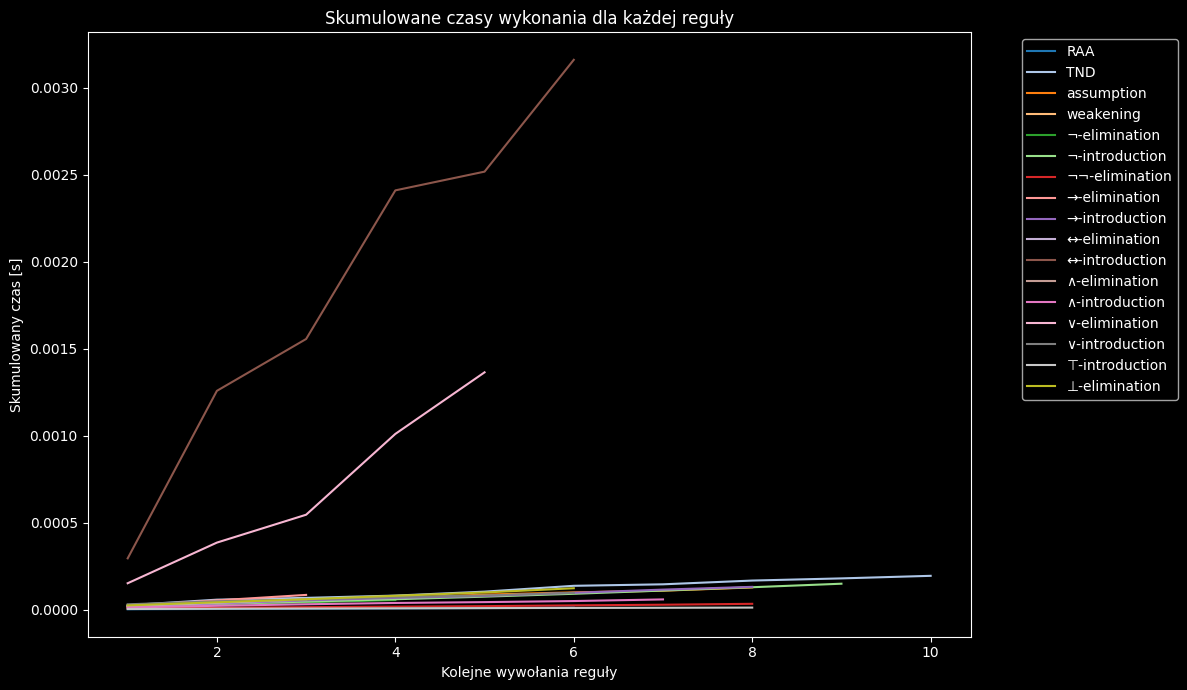

In [87]:
import matplotlib.pyplot as plt

timings = getattr(RandomProofLine, "_timings", None)
if timings is None or len(timings) == 0:
    print("Brak zebranych timingów w RandomProofLine._timings")
else:
    rules = sorted(timings.keys())

    plt.figure(figsize=(12, 7))

    # 1. Własny cykl kolorów (więcej niż domyślne)
    colors = plt.cm.tab20.colors   # 20 wyraźnych kolorów
    linestyles = ['-', '--', '-.', ':']
    markers = ['', 'o', 's', 'D', '^', 'v']

    for i, rule in enumerate(rules):
        vals = timings[rule]
        if not vals:
            continue

        cumulative = []
        s = 0.0
        for v in vals:
            s += v
            cumulative.append(s)

        color = colors[i % len(colors)]
        ls = linestyles[(i // len(colors)) % len(linestyles)]
        marker = markers[(i // (len(colors) * len(linestyles))) % len(markers)]

        plt.plot(
            range(1, len(cumulative) + 1),
            cumulative,
            label=rule,
            color=color,
            linestyle=ls,
            marker=marker,
            linewidth=1.5
        )

    plt.xlabel("Kolejne wywołania reguły")
    plt.ylabel("Skumulowany czas [s]")
    plt.title("Skumulowane czasy wykonania dla każdej reguły")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [88]:
l = []
for i in timings.keys():
    l.append([i,sum(timings[i])])
l.sort(key=lambda x: -x[1])
for i in l:
    print(i)

['↔-introduction', 0.0031604170362697914]
['∨-elimination', 0.0013636189978569746]
['TND', 0.00019374200201127678]
['¬-introduction', 0.00014839402865618467]
['→-introduction', 0.00013032302376814187]
['assumption', 0.00012691599840763956]
['⊥-elimination', 0.0001223390136146918]
['∨-introduction', 9.589100955054164e-05]
['→-elimination', 8.400798833463341e-05]
['∧-introduction', 5.8088015066459775e-05]
['↔-elimination', 5.728899850510061e-05]
['¬-elimination', 5.440799577627331e-05]
['weakening', 4.8389003495685756e-05]
['¬¬-elimination', 3.2854994060471654e-05]
['⊤-introduction', 1.1096970411017537e-05]
['RAA', 1.1011987226083875e-05]
['∧-elimination', 4.83199255540967e-06]


In [89]:
print(proof_so_far_structure)
for i in range(proof_so_far_structure.__len__()):
    if proof_so_far_structure[i].assumptions.formulas == []:
        print(proof.splitlines()[i])

[R17(p) | R17(q) ⊢ R17(p) | R17(q), R17(p), R17(p) | R17(q) ⊢ R17(p), R17(p), R17(p) | R17(q) ⊢ R17(q) | R17(p), R17(q), R17(p) | R17(q) ⊢ R17(q), R17(q), R17(p) | R17(q) ⊢ R17(q) | R17(p), R17(p) | R17(q) ⊢ R17(q) | R17(p),  ⊢ (R17(p) | R17(q)) -> (R17(q) | R17(p)), ~~R17(p) ⊢ ~~R17(p), R17(p) <-> R17(q) ⊢ R17(p) <-> R17(q), ⊥ ⊢ ⊥, R17(p), R17(p) | R17(q) ⊢ (R17(q) | R17(p)) | ~R17(c), R17(a) & R17(s) ⊢ R17(a) & R17(s), ~~R17(p) ⊢ R17(p), ~~R17(p) ⊢ R17(p),  ⊢ ((R17(t) & R17(q)) <-> (R17(q) | R17(d))) | ~((R17(t) & R17(q)) <-> (R17(q) | R17(d))), ~~R17(p) ⊢ R17(p),  ⊢ ((R17(u) | R17(r)) <-> (R17(b) -> (~R17(t) & R17(c)))) | ~((R17(u) | R17(r)) <-> (R17(b) -> (~R17(t) & R17(c)))),  ⊢ ~R17(a) | ~~R17(a),  ⊢ ~⊥, R17(a) & R17(s) ⊢ R17(s),  ⊢ ~⊥, R17(c) & R17(y) ⊢ R17(c) & R17(y), ~~R17(p) ⊢ R17(p), ~~R17(p) ⊢ R17(p) & ((R17(p) | R17(q)) -> (R17(q) | R17(p))), (R17(q) & R17(d)) -> (R17(u) <-> R17(y)) ⊢ (R17(q) & R17(d)) -> (R17(u) <-> R17(y)),  ⊢ ~⊥, R17(p) | R17(q) ⊢ R17(p) <-> R17(p),  ⊢

IndexError: list index out of range

In [ ]:
print(proof)

In [ ]:

if isinstance(proof, str):
    proof = proof.splitlines()
table = []
for i in range(proof_so_far_structure.__len__()):
    if proof[i].split()[-1] not in ["assumption","TND","⊤-introduction"]:
        table.append([i,proof_so_far_structure[i].assumptions.formulas.__len__()])
    else:
        print(proof[i].split()[-1])
print(table)

In [ ]:
for i in table:
    if i[1] == 0:
        if FreeVariables(proof_so_far_structure[i[0]].conclusion) != set():
            print(i,to_infix(proof_so_far_structure[i[0]].conclusion))

In [ ]:
def variables_order(f):
    if isinstance(f,Lie) or isinstance(f,Truth):
        return []
    if isinstance(f,Atom):
        return [f]
    else:
        ans = []
        for i in f.Interior:
            ans += variables_order(i)
        return ans
def contains_TF(f):
    if isinstance(f,Truth) or isinstance(f,Lie):
        return True
    if isinstance(f,Atom):
        return False
    else:
        ans  = False
        for i in f.Interior:
            ans = ans or contains_TF(i)
        return ans
for i in table:
    if i[1] == 0:
        if FreeVariables(proof_so_far_structure[i[0]].conclusion) != set():
            if not contains_TF(proof_so_far_structure[i[0]].conclusion):
                print(i,to_infix(proof_so_far_structure[i[0]].conclusion))

In [ ]:
import re
def extract_proof(proof, line_number):
    if  isinstance(proof, str):
        proof = proof.splitlines()
    idxs = set()
    idxs.add(line_number-1)
    new_idxs = set()#te które mamy w zbiorze, ale nie mamy jeszcze ich sąsiadów
    new_idxs.add(line_number-1)
    while new_idxs.__len__() != 0:
        i = random.choice(list(new_idxs))
        new_idxs.remove(i)
        newest_idxs = re.findall(r"\d+",proof[i])
        for j in newest_idxs:
            if not int(j)-1 in idxs:
                idxs.add(int(j)-1)
                new_idxs.add(int(j)-1)
    idxs = sorted(list(idxs))
    ans = ""
    for i in idxs:
        ans += proof[i] +"\n"
    ans = ans.splitlines()
    for i in range(ans.__len__()):
        ans[i] = re.split(r"([. ,–])",ans[i])
    new_idxs = dict()
    for i in range(idxs.__len__()):
        new_idxs[str(idxs[i]+1)] = str(i+1)
    for i in range(ans.__len__()):
        for j in range(ans[i].__len__()):
            if ans[i][j] in new_idxs.keys():
                ans[i][j] = new_idxs[ans[i][j]]
    for i in range(ans.__len__()):
        new_line = ""
        for j in ans[i]:
            new_line += j
        ans[i] = new_line
    final_ans = ""
    for i in ans:
        final_ans += i
        final_ans += "\n"
    return final_ans[:-1]

print()
little_proof =  extract_proof(proof, 100)
print(little_proof)
check_proof(little_proof)

In [ ]:
proofs_of_tautologies = []
proof = """1.  p ∨ q                          assumption
2.    p                             weakening, 1
3.    q ∨ p                         ∨-introduction, 2
4.    q                             weakening, 1
5.    q ∨ p                         ∨-introduction, 4
6.  q ∨ p                           ∨-elimination, 1, 2–3, 4–5
7.  (p ∨ q) → (q ∨ p)               →-introduction, 1–6
8.  ¬¬p                 assumption
9.    p ↔ q      assumption
10.   ⊥     assumption
"""
'''
for z in range(100):
    print(z)
    proof_so_far_structure = check_proof(proof)
    in_which_context_is_formula = dict()
    for i in range(proof_so_far_structure.__len__()):
        for j in proof_so_far_structure[i].assumptions.formulas:
            if not j in in_which_context_is_formula.keys():
                in_which_context_is_formula[j] = [i]
            else:
                in_which_context_is_formula[j].append(i)
    for i in tqdm(range(1000)):
        next_line = RandomProofLine(list("abcdpqrstuvwxyz"), proof, proof_so_far_structure, 10,TruthLieIncluded = False)
        if next_line != "":
            #print(next_line)
            proof = proof + next_line[0] + "\n"
            proof_so_far_structure.append(next_line[1])
            for j in next_line[1].assumptions.formulas:
                if not j in in_which_context_is_formula.keys():
                    in_which_context_is_formula[j] = [proof_so_far_structure.__len__()-1]
                else:
                    in_which_context_is_formula[j].append(proof_so_far_structure.__len__()-1)

    #print(proof)
    check_proof(proof)
    if isinstance(proof,str):
        proof = proof.splitlines()
    for i in range(proof_so_far_structure.__len__()):
        if proof_so_far_structure[i].assumptions.formulas == []:
            if not contains_TF(proof_so_far_structure[i].conclusion):
                #print(i,proof[i])
                little_proof = extract_proof(proof,i+1)
                #print(little_proof)
                #print()
                #print()
                if little_proof.splitlines().__len__() > 2:
                    proofs_of_tautologies.append(little_proof)
    proof = random.choice(proofs_of_tautologies)+"\n"
'''

In [ ]:
proofs_of_tautologies

In [ ]:
# Python
from ast import literal_eval
with open("input.txt", "r", encoding="utf-8") as f:
    x = f.read()  # bezpieczne wczytanie listy

In [ ]:
'''generuję sobie losowe dowody tautologii tutaj(tak, wiem zakomentowane, bo generowało to się długo) i chce zrobić sobie korpus dowodów na których mógłbym uczyć LM-a. problem polega na tym, że dowodzone tautologie są zwykle bardzo do siebie podobne, np mają jakieś podformuły które są tautologiami, są homomorficzne z jakimiś bardzo prostymi przypadkami typu a lub nie a gdzie za a są podstawiane jakieś losowe formuły, przez co korpus ten będzie mało użyteczny raczej. Jak temu zadziałać'''

In [ ]:
def subformulas(f):
    if not isinstance(f,Formula):
        raise TypeError("Bad argument")
    if isinstance(f,Atom) or isinstance(f,Truth) or isinstance(f,Lie):
        return []
    ans = []
    for i in f.Interior:
        ans.append(i)
        ans += subformulas(i)
    return ans


In [ ]:
def AbstractionSimple(t,x,Expr):
    if t == Expr:
        return parse_infix(x)
    if isinstance(Expr,Truth) or isinstance(Expr,Lie) or isinstance(Expr,Atom):
        return Expr
    ExprAns = copy.deepcopy(Expr)
    for i in range(Expr.Interior.__len__()):
        ExprAns.Interior[i] = AbstractionSimple(t,x,ExprAns.Interior[i])
    return ExprAns

In [ ]:

def normalise(f):
    vars = variables_order(f)
    i = 0
    new_vars = dict()
    for x in vars:
        if not to_infix(x) in new_vars.keys():
            new_vars[to_infix(x)] = "x" + str(i)
            i += 1
    ans = copy.deepcopy(f)
    for old in new_vars.keys():
        new = new_vars[old]
        ans = AbstractionSimple(parse_infix(old), new, ans)
    return ans

In [ ]:
def homomorphic(f):
    f_norm = normalise(f)
    sub_forms = subformulas(f_norm)
    ans = []
    new_var = "x"+str(to_infix(f_norm).__len__())
    for i in sub_forms:
        if not (isinstance(i,Atom) or isinstance(i,Truth) or isinstance(i,Lie)):
            new_elem  = AbstractionSimple(i, new_var,f_norm)
            ans.append(normalise(new_elem))
            ans += homomorphic(ans[-1])
    print(ans.__len__())
    return ans

def can_be_simplified(f):
    if not isTautology(f):
        return None
    f_norm = normalise(f)
    new_var = "x"+str(to_infix(f_norm).__len__())
    sub_forms = subformulas(f_norm)
    for i in sub_forms:
        if not (isinstance(i,Atom) or isinstance(i,Truth) or isinstance(i,Lie)):
            if isTautology(i) == Truth():
                new_candidate = AbstractionSimple(i, "T",f_norm)###
                return can_be_simplified(new_candidate) + np.log(to_infix(f_norm).__len__()-to_infix(normalise(i)).__len__())
            if isTautology(Negation(i)) == Truth():
                new_candidate = AbstractionSimple(i, "⊥",f_norm)###
                return can_be_simplified(new_candidate) + np.log(to_infix(f_norm).__len__()-to_infix(normalise(i)).__len__())
            new_candidate  = AbstractionSimple(i, new_var,f_norm)
            if isTautology(new_candidate):
                return can_be_simplified(new_candidate) + np.log(to_infix(f_norm).__len__()-to_infix(normalise(i)).__len__())
    return 0



In [ ]:
isTautology(Lie())

In [ ]:
'''
for i in x:
    i_structure = check_proof(i)
    if can_be_simplified(i_structure[-1].conclusion) == False:
        print(i_structure[-1].conclusion)
'''
def depth(f):
    if isinstance(f,Atom) or isinstance(f,Truth) or isinstance(f,Lie):
        return 1
    else:
        ans = 0
        for i in f.Interior:
            if depth(i) > ans:
                ans = depth(i)
        return ans + 1


In [ ]:
how_many_times_was = dict()
def score(lp):
    global how_many_times_was
    ans = 0
    if can_be_simplified(lp.conclusion) != None:
        ans -= can_be_simplified(lp.conclusion) *10
    if normalise(lp.conclusion) in how_many_times_was.keys():
        ans -= how_many_times_was[normalise(lp.conclusion)]*5
    ans -= lp.assumptions.formulas.__len__()
    ans += np.log(to_infix(normalise(lp.conclusion)).__len__())
    if isinstance(lp.conclusion,Implication) or isinstance(lp.conclusion,Iff):
        if lp.conclusion.Left() == lp.conclusion.Right():
            ans -= 1000
    return ans
#lp = check_proof(x[1])[1]
#print(lp)
#how_many_times_was[normalise(lp.conclusion)] = 1
#score(lp)


In [ ]:
proofs_of_tautologies = []
how_many_times_was = dict()
proof = """1.  p ∨ q                          assumption
2.    p                             weakening, 1
3.    q ∨ p                         ∨-introduction, 2
4.    q                             weakening, 1
5.    q ∨ p                         ∨-introduction, 4
6.  q ∨ p                           ∨-elimination, 1, 3, 5
7.  (p ∨ q) → (q ∨ p)               →-introduction, 1–6
8.  ¬¬p                 assumption
9.    p ↔ q      assumption
10.   ⊥     assumption
"""
from math import isnan
import numpy as np
for z in range(1):
    print(z)
    proof_so_far_structure = check_proof(proof)
    in_which_context_is_formula = dict()
    which_conclusion_is_formula = dict()
    for i in range(proof_so_far_structure.__len__()):
        for j in proof_so_far_structure[i].assumptions.formulas:
            if not j in in_which_context_is_formula.keys():
                in_which_context_is_formula[j] = [i]
            else:
                in_which_context_is_formula[j].append(i)
        if proof_so_far_structure[i].conclusion in which_conclusion_is_formula.keys():
            which_conclusion_is_formula[proof_so_far_structure[i].conclusion].append(i)
        else:
            which_conclusion_is_formula[proof_so_far_structure[i].conclusion] = [i]
    for i in tqdm(range(1000)):
        next_lines = []
        probabilities = []
        for j in range(10):
            next_line = ""
            next_line = RandomProofLine(list("abcdpqrstuvwxyz"), proof, proof_so_far_structure,in_which_context_is_formula, which_conclusion_is_formula, 10,TruthLieIncluded = False)
            if next_line != "":
                next_lines.append(next_line)
                probabilities.append(score(next_line[1]))
        if next_lines.__len__() > 0:
            probabilities = np.array(probabilities,dtype=float)

            probabilities = probabilities - probabilities.min()
            for j in range(probabilities.__len__()):
                probabilities[j] += 0.00001
            probabilities = probabilities/probabilities.sum()
            for j in range(probabilities.__len__()):
                if isnan(probabilities[j]):
                    probabilities[j] = 1
            idx = np.random.choice(next_lines.__len__(), p = probabilities)
            next_line = next_lines[idx]
            if not normalise(next_line[1].conclusion) in how_many_times_was.keys():
                how_many_times_was[normalise(next_line[1].conclusion)] = 1
            else:
                how_many_times_was[normalise(next_line[1].conclusion)] += 1
            if next_line != "":
                #print(next_line)
                proof = proof + next_line[0] + "\n"
                proof_so_far_structure.append(next_line[1])
                for j in next_line[1].assumptions.formulas:
                    if not j in in_which_context_is_formula.keys():
                        in_which_context_is_formula[j] = [proof_so_far_structure.__len__()-1]
                    else:
                        in_which_context_is_formula[j].append(proof_so_far_structure.__len__()-1)
                if next_line[1].conclusion in which_conclusion_is_formula.keys():
                    which_conclusion_is_formula[next_line[1].conclusion].append(proof_so_far_structure.__len__()-1)
                else:
                    which_conclusion_is_formula[next_line[1].conclusion] = [proof_so_far_structure.__len__()-1]
    #print(proof)
    check_proof(proof)
    if isinstance(proof,str):
        proof = proof.splitlines()
    for i in range(proof_so_far_structure.__len__()):
        if proof_so_far_structure[i].assumptions.formulas == []:
            if not contains_TF(proof_so_far_structure[i].conclusion):
                #print(i,proof[i])
                little_proof = extract_proof(proof,i+1)
                #print(little_proof)
                #print()
                #print()
                if little_proof.splitlines().__len__() > 2:
                    proofs_of_tautologies.append(little_proof)
    proof = random.choice(proofs_of_tautologies)+"\n"

In [ ]:
for i in proofs_of_tautologies:
    print(i)
    print()

In [ ]:

with open("korpusv3", "r", encoding="utf-8") as f:
    proofs_of_tautologies = literal_eval(f.read())  # bezpieczne wczytanie listy


#with open("korpusv2", "w", encoding="utf-8") as f:
#    for p in proofs_of_tautologies:
#        f.write(repr(p) + ",\n")

In [ ]:
for i in range(proofs_of_tautologies.__len__()):
    proof_so_far_structure = check_proof(proofs_of_tautologies[i])
    tautology = proof_so_far_structure[-1].conclusion
    print(to_infix(tautology))

In [ ]:
with open("korpusv3", "w") as f:
    print("[", file=f)
    for i in proofs_of_tautologies:
        print(i,file=f)
        print("\'\'\',\n\'\'\'",file=f)

In [ ]:
proofs_of_tautologies_structure = []
for i in proofs_of_tautologies:
    proofs_of_tautologies_structure.append(check_proof(i))

In [ ]:
with open("KorpusV1","w") as f:
    for i in range(proofs_of_tautologies.__len__()):
        print("Prove that: ",to_infix(proofs_of_tautologies_structure[i][-1].conclusion),file = f)
        print(proofs_of_tautologies[i],file = f)
        print(file = f)

In [ ]:
for i , I in enumerate(proof_so_far_structure):
    if I.assumptions.formulas == []:
        if proof.splitlines()[i].split()[-1] != "TND":
            if proof.splitlines()[i].split()[-1] != "⊤-introduction":
                print(proof.splitlines()[i])

In [ ]:
print(sys.path)
import model
print(model)
# Wyświetl wszystko, co nie jest "systemowe" (nie zaczyna się od __)
print([item for item in dir(model) if not item.startswith("__")])

# Zabawy transformerami


In [ ]:
import torch
from model import GPT, GPTConfig
import os
import numpy as np

# 1) wczytujemy config tak jak w sample.py
exec(open('../nanoGPT/config/trainKorpusV1.py').read())
# teraz masz w przestrzeni nazw takie zmienne jak:
# block_size, batch_size, n_layer, n_head, n_embd, max_iters, lr, etc.
# + dataset (np. "shakespeare_char")

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 2) wczytujemy binarki z tokenami
data_dir = os.path.join('../nanoGPT/data', "KorpusV1")
print(data_dir)

train_mm = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
train_data = torch.from_numpy(train_mm.astype(np.int64))  # lub np.int32, byle spójnie z modelem

# wczytywanie danych walidacyjnych
val_mm = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
val_data = torch.from_numpy(val_mm.astype(np.int64))

print(train_data.shape, train_data.dtype)
print(val_data.shape, val_data.dtype)
'''
train_data = torch.from_numpy(
    torch.load(os.path.join(data_dir, 'train.bin'))
) if isinstance(torch.load(os.path.join(data_dir, 'train.bin')), torch.Tensor) else torch.from_numpy(
    np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
)
# w oryginale używany jest np.memmap; możesz też zrobić prościej:
# train_data = torch.from_numpy(np.memmap(...))

val_data = torch.from_numpy(
    torch.load(os.path.join(data_dir, 'val.bin'))
) if isinstance(torch.load(os.path.join(data_dir, 'val.bin')), torch.Tensor) else torch.from_numpy(
    np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
)

'''

In [ ]:
block_size = 1024
batch_size = 6
def get_batch(split):
    data = train_data if split == 'train' else val_data
    # losujemy startowe indeksy sekwencji
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size]     for i in ix])
    y = torch.stack([data[i+1:i+1+block_size] for i in ix])
    x = x.to(device)
    y = y.to(device)
    return x, y


In [ ]:
# zakładam, że w configu masz zmienną vocab_size
vocab_size :int = 500#50304
n_layer = 6
n_head =6
n_embd = 384
gptconf = GPTConfig(
    vocab_size=vocab_size,
    block_size=block_size,
    n_layer=n_layer,
    n_head=n_head,
    n_embd=n_embd
    # możesz dodać inne parametry z configu, np. dropout itd.
)

model = GPT(gptconf)
model.to(device)
learning_rate = 1e-3
# optymalizator (jak w train.py)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)


In [ ]:
# uproszczona pętla treningowa
import gc, torch

gc.collect()
torch.cuda.empty_cache()
for iter in range(max_iters):
    model.train()
    x, y = get_batch('train')

    # forward – zgodnie z modelem nanoGPT:
    # logits: [B, T, vocab_size], loss: scalar
    logits, loss = model(x, y)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if iter % eval_interval == 0:
        # ewaluacja na val
        model.eval()
        with torch.no_grad():
            vx, vy = get_batch('val')
            v_logits, v_loss = model(vx, vy)
        print(f"iter {iter}: train loss {loss.item():.4f}, val loss {v_loss.item():.4f}")


In [ ]:
import torch

# ile jest dostępnej pamięci (w bajtach)
torch.cuda.empty_cache()
free_mem, total_mem = torch.cuda.mem_get_info()
torch.cuda.reset_peak_memory_stats()
torch.cuda.empty_cache()
print("Wolna pamięć (GB):", free_mem / 1024**3)
print("Całkowita pamięć (GB):", total_mem / 1024**3)
